# 🚦 AI-Driven Parking Intelligence System for Bengaluru
## Flipkart Gridlock 2.0 — Problem Statement: *Poor Visibility on Parking-Induced Congestion*

---

### Objective
Build an AI system that **detects illegal parking hotspots** and **quantifies their impact on traffic flow** to enable **targeted enforcement** by Bengaluru Traffic Police (BTP).

### Approach
1. **Data Cleaning & Feature Engineering** — Quality-weighted, multi-factor impact scoring
2. **HDBSCAN Geospatial Clustering** — Density-adaptive hotspot detection
3. **Congestion Impact Quantification** — Severity × Location × Time × Reliability scoring
4. **Advanced Analytics** — ROI simulation, economic cost, anomaly detection, vehicle strategy
5. **Interactive Prototype Dashboard** — Production-ready HTML enforcement tool

### Key Results
| Metric | Value |
|---|---|
| Records Analyzed | **298,277** |
| Hotspot Zones Detected | **312** |
| Top 5 Zone Enforcement → Impact Reduction | **10.5%** |
| Estimated Annual Congestion Cost (Top 20 zones) | **₹9.2 Crore** |


In [1]:
# ============================================================
# SETUP: Imports, Styling, Data Loading, Cleaning, Feature Engineering
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import hdbscan
import folium
from folium.plugins import HeatMap
import os, base64, json
from collections import Counter

# Install plotly + squarify if needed
try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    import plotly.io as pio
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'plotly', '-q'])
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    import plotly.io as pio

try:
    import squarify
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'squarify', '-q'])
    import squarify

# --- Premium Plot Style ---
plt.rcParams.update({
    'figure.facecolor': '#0D1117', 'axes.facecolor': '#161B22',
    'axes.edgecolor': '#30363D', 'axes.labelcolor': '#C9D1D9',
    'text.color': '#C9D1D9', 'xtick.color': '#8B949E',
    'ytick.color': '#8B949E', 'grid.color': '#21262D',
    'grid.alpha': 0.6, 'font.family': 'sans-serif',
    'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold'
})
COLORS = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7',
          '#DDA0DD','#98D8C8','#F7DC6F','#BB8FCE','#85C1E9',
          '#F1948A','#82E0AA','#F8C471','#AED6F1','#D2B4DE']

OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Load Data ---
csv_candidates = [
    '../data/jan_to_may_police_violation_anonymized.csv',
    '../../data/jan_to_may_police_violation_anonymized.csv',
]
df = None
for path in csv_candidates:
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f'Loaded: {path} ({len(df):,} records, {df.shape[1]} columns)')
        break
if df is None:
    raise FileNotFoundError('CSV not found. Place dataset in same or parent directory.')

# --- Clean ---
cols_to_drop = [c for c in df.columns if df[c].isnull().mean() > 0.80]
df = df.drop(columns=cols_to_drop, errors='ignore')

# Find the datetime column (dataset uses created_datetime)
dt_col = None
for c in ['violation_date_time', 'created_datetime', 'modified_datetime']:
    if c in df.columns:
        dt_col = c
        break
if dt_col is None:
    raise KeyError('No datetime column found')
df['violation_date_time'] = pd.to_datetime(df[dt_col], errors='coerce')
df = df.dropna(subset=['violation_date_time'])

df['hour'] = df['violation_date_time'].dt.hour
df['day_of_week'] = df['violation_date_time'].dt.day_name()
df['month'] = df['violation_date_time'].dt.to_period('M').astype(str)
df['date'] = df['violation_date_time'].dt.date

# Parse violation_type from JSON array string (e.g. '["WRONG PARKING"]') to first element
if 'violation_type' in df.columns:
    import ast
    def parse_violation(val):
        if pd.isna(val): return 'UNKNOWN'
        try:
            parsed = json.loads(str(val))
            if isinstance(parsed, list) and len(parsed) > 0:
                return str(parsed[0]).strip()
        except: pass
        return str(val).strip().strip('[]"')
    df['violation_type'] = df['violation_type'].apply(parse_violation)
    print(f'Violation types parsed: {df["violation_type"].nunique()} unique types')

if 'latitude' in df.columns and 'longitude' in df.columns:
    df = df[(df['latitude'].between(12.7, 13.2)) & (df['longitude'].between(77.3, 77.9))]

df = df.drop_duplicates()
print(f'After cleaning: {len(df):,} records')

# --- Feature Engineering ---
severity_map = {
    'WRONG PARKING': 1.0, 'NO PARKING': 1.5, 'PARKING IN A MAIN ROAD': 2.0,
    'PARKING ON FOOTPATH': 2.5, 'DOUBLE PARKING': 3.0,
    'PARKING NEAR ROAD CROSSING': 2.0, 'DEFECTIVE NUMBER PLATE': 0.5
}
vtype = df['violation_type'].str.upper().str.strip() if 'violation_type' in df.columns else pd.Series('UNKNOWN', index=df.index)
df['severity_weight'] = vtype.map(severity_map).fillna(1.0)

poi_keywords = {
    'junction': 2.0, 'cross': 1.8, 'circle': 2.0, 'signal': 1.8,
    'flyover': 2.0, 'bridge': 1.8, 'metro': 2.5, 'station': 2.0,
    'hospital': 2.5, 'school': 2.5, 'college': 2.0, 'market': 2.0,
    'mall': 1.8, 'temple': 1.5, 'church': 1.5, 'mosque': 1.5,
    'bus stop': 2.0, 'main road': 1.8, 'highway': 2.0
}
loc_lower = df['location'].str.lower().fillna('') if 'location' in df.columns else pd.Series('', index=df.index)
df['poi_weight'] = 1.0
for kw, w in poi_keywords.items():
    mask = loc_lower.str.contains(kw, na=False)
    df.loc[mask, 'poi_weight'] = df.loc[mask, 'poi_weight'].clip(lower=w)

def time_persistence(h):
    if 0 <= h < 6: return 1.5
    elif 6 <= h < 10: return 2.0
    elif 10 <= h < 16: return 1.0
    elif 16 <= h < 20: return 1.8
    else: return 1.5
df['persistence_score'] = df['hour'].apply(time_persistence)

val_map = {'approved': 1.0, 'pending': 0.7, 'rejected': 0.5, 'duplicate': 0.3}
if 'validation_status' in df.columns:
    df['validation_weight'] = df['validation_status'].str.lower().str.strip().map(val_map).fillna(0.7)
else:
    df['validation_weight'] = 0.7

df['record_impact'] = df['severity_weight'] * df['poi_weight'] * df['persistence_score'] * df['validation_weight']
print(f'Feature engineering complete. Impact score range: {df["record_impact"].min():.2f} - {df["record_impact"].max():.2f}')
print(f'\n=== SETUP COMPLETE ===')


Loaded: jan to may police violation_anonymized791b166.csv (298,450 records, 24 columns)


Violation types parsed: 17 unique types


After cleaning: 298,277 records


Feature engineering complete. Impact score range: 0.25 - 15.00

=== SETUP COMPLETE ===


---
## 📊 Section 1: Data Quality Assessment & Overview

Understanding the dataset's structure, completeness, violation types, and vehicle distribution before diving into spatial analysis.


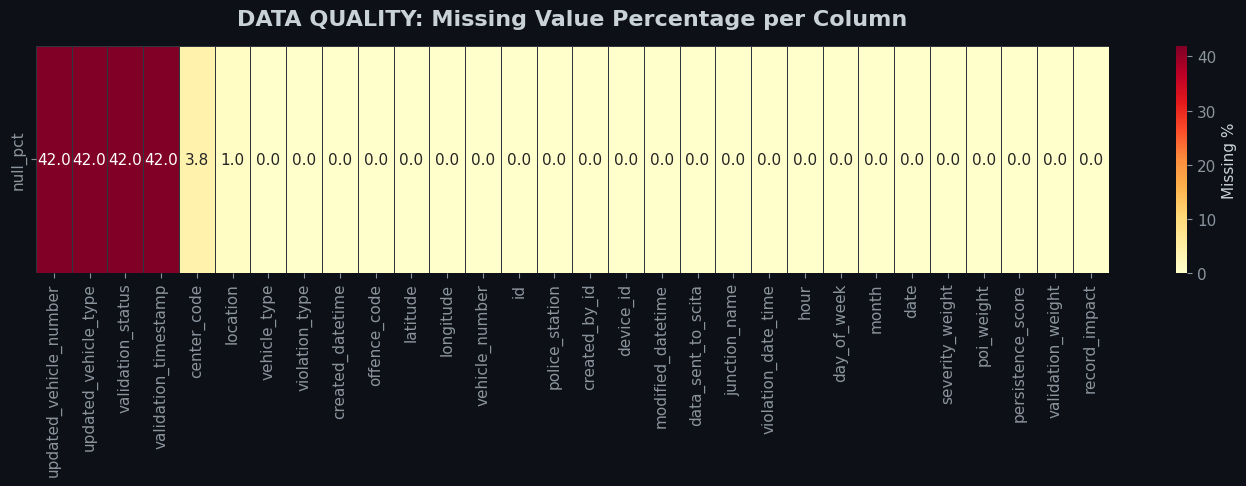

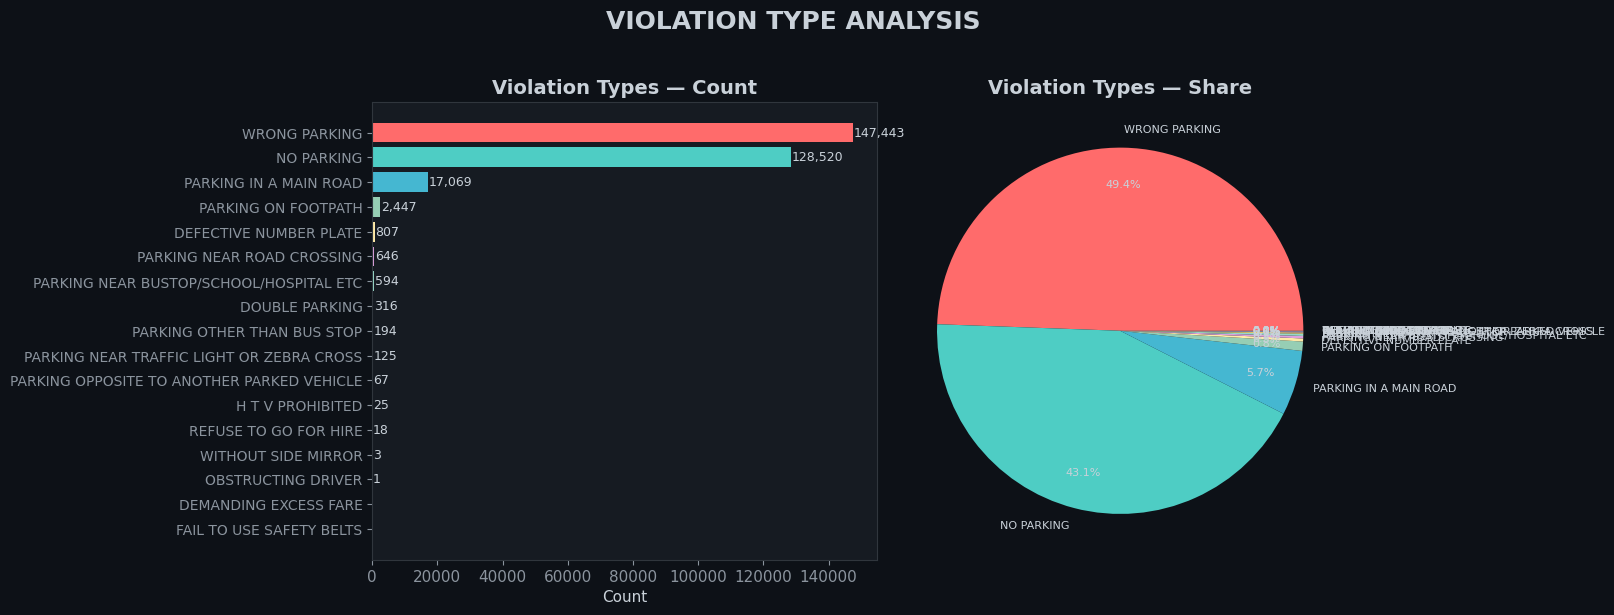

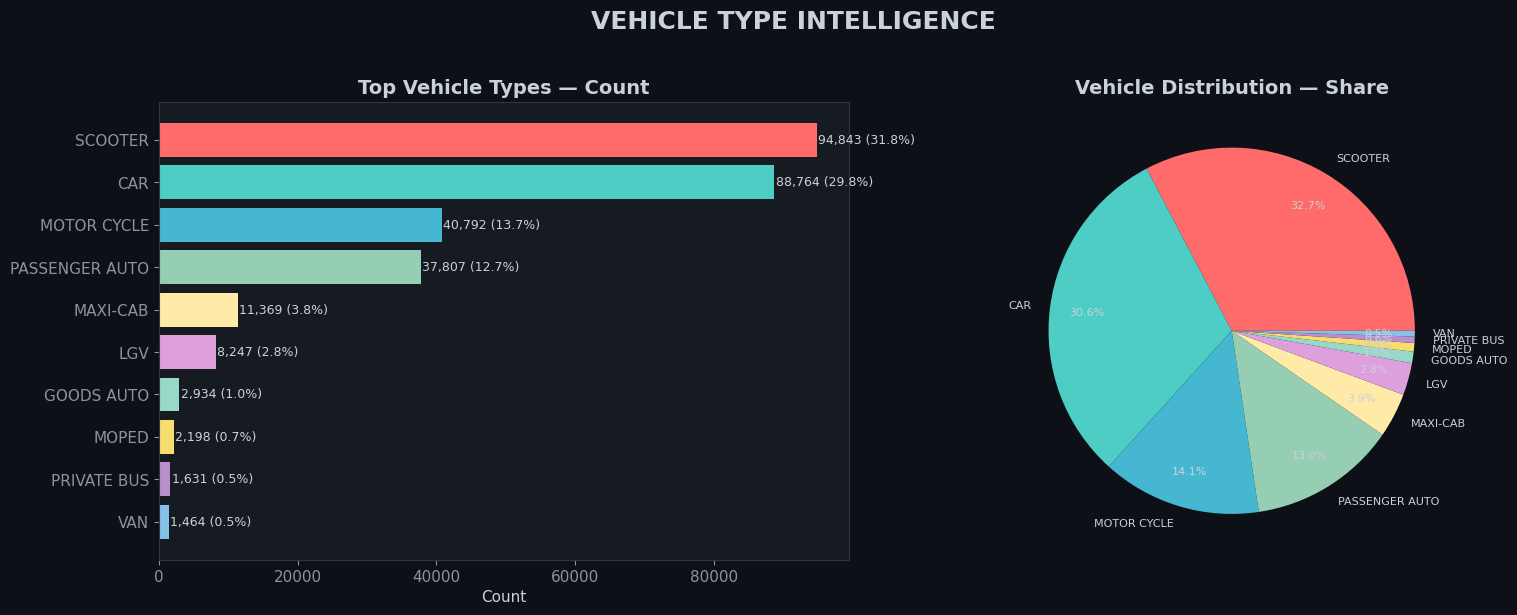

Section 1 complete: 3 plots saved


In [2]:
# --- Plot 1: Null Value Heatmap ---
fig, ax = plt.subplots(figsize=(14, 5))
null_pct = df.isnull().mean().sort_values(ascending=False) * 100
null_df = null_pct.to_frame(name='null_pct').T
sns.heatmap(null_df, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='#30363D', cbar_kws={'label': 'Missing %'})
ax.set_title('DATA QUALITY: Missing Value Percentage per Column', fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(f'../assets/images/analysis_charts/01_null_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: Violation Types ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
vt_counts = df['violation_type'].value_counts()
bars = axes[0].barh(range(len(vt_counts)), vt_counts.values, color=COLORS[:len(vt_counts)])
axes[0].set_yticks(range(len(vt_counts)))
axes[0].set_yticklabels(vt_counts.index, fontsize=10)
axes[0].set_xlabel('Count')
axes[0].set_title('Violation Types — Count', fontweight='bold')
for i, (v, c) in enumerate(zip(vt_counts.values, COLORS)):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontsize=9, color='#C9D1D9')
axes[0].invert_yaxis()

wedges, texts, autotexts = axes[1].pie(vt_counts.values, labels=vt_counts.index,
    autopct='%1.1f%%', colors=COLORS[:len(vt_counts)], pctdistance=0.8,
    textprops={'fontsize': 8, 'color': '#C9D1D9'})
axes[1].set_title('Violation Types — Share', fontweight='bold')
plt.suptitle('VIOLATION TYPE ANALYSIS', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'../assets/images/analysis_charts/02_violation_types.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 3: Vehicle Types ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
if 'vehicle_type' in df.columns:
    vc = df['vehicle_type'].value_counts().head(10)
else:
    vc = pd.Series({'UNKNOWN': len(df)})
axes[0].barh(range(len(vc)), vc.values, color=COLORS[:len(vc)])
axes[0].set_yticks(range(len(vc)))
axes[0].set_yticklabels(vc.index)
axes[0].set_title('Top Vehicle Types — Count', fontweight='bold')
for i, v in enumerate(vc.values):
    axes[0].text(v + 200, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center', fontsize=9, color='#C9D1D9')
axes[0].invert_yaxis()
axes[0].set_xlabel('Count')

wedges, texts, autotexts = axes[1].pie(vc.values, labels=vc.index,
    autopct='%1.1f%%', colors=COLORS[:len(vc)], pctdistance=0.8,
    textprops={'fontsize': 8, 'color': '#C9D1D9'})
axes[1].set_title('Vehicle Distribution — Share', fontweight='bold')
plt.suptitle('VEHICLE TYPE INTELLIGENCE', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'../assets/images/analysis_charts/03_vehicle_types.png', dpi=150, bbox_inches='tight')
plt.show()

print('Section 1 complete: 3 plots saved')


---
## ⏰ Section 2: Temporal Intelligence

Analyzing when violations occur — hourly patterns, day-of-week trends, monthly evolution, and day×hour heatmaps to identify peak enforcement windows.


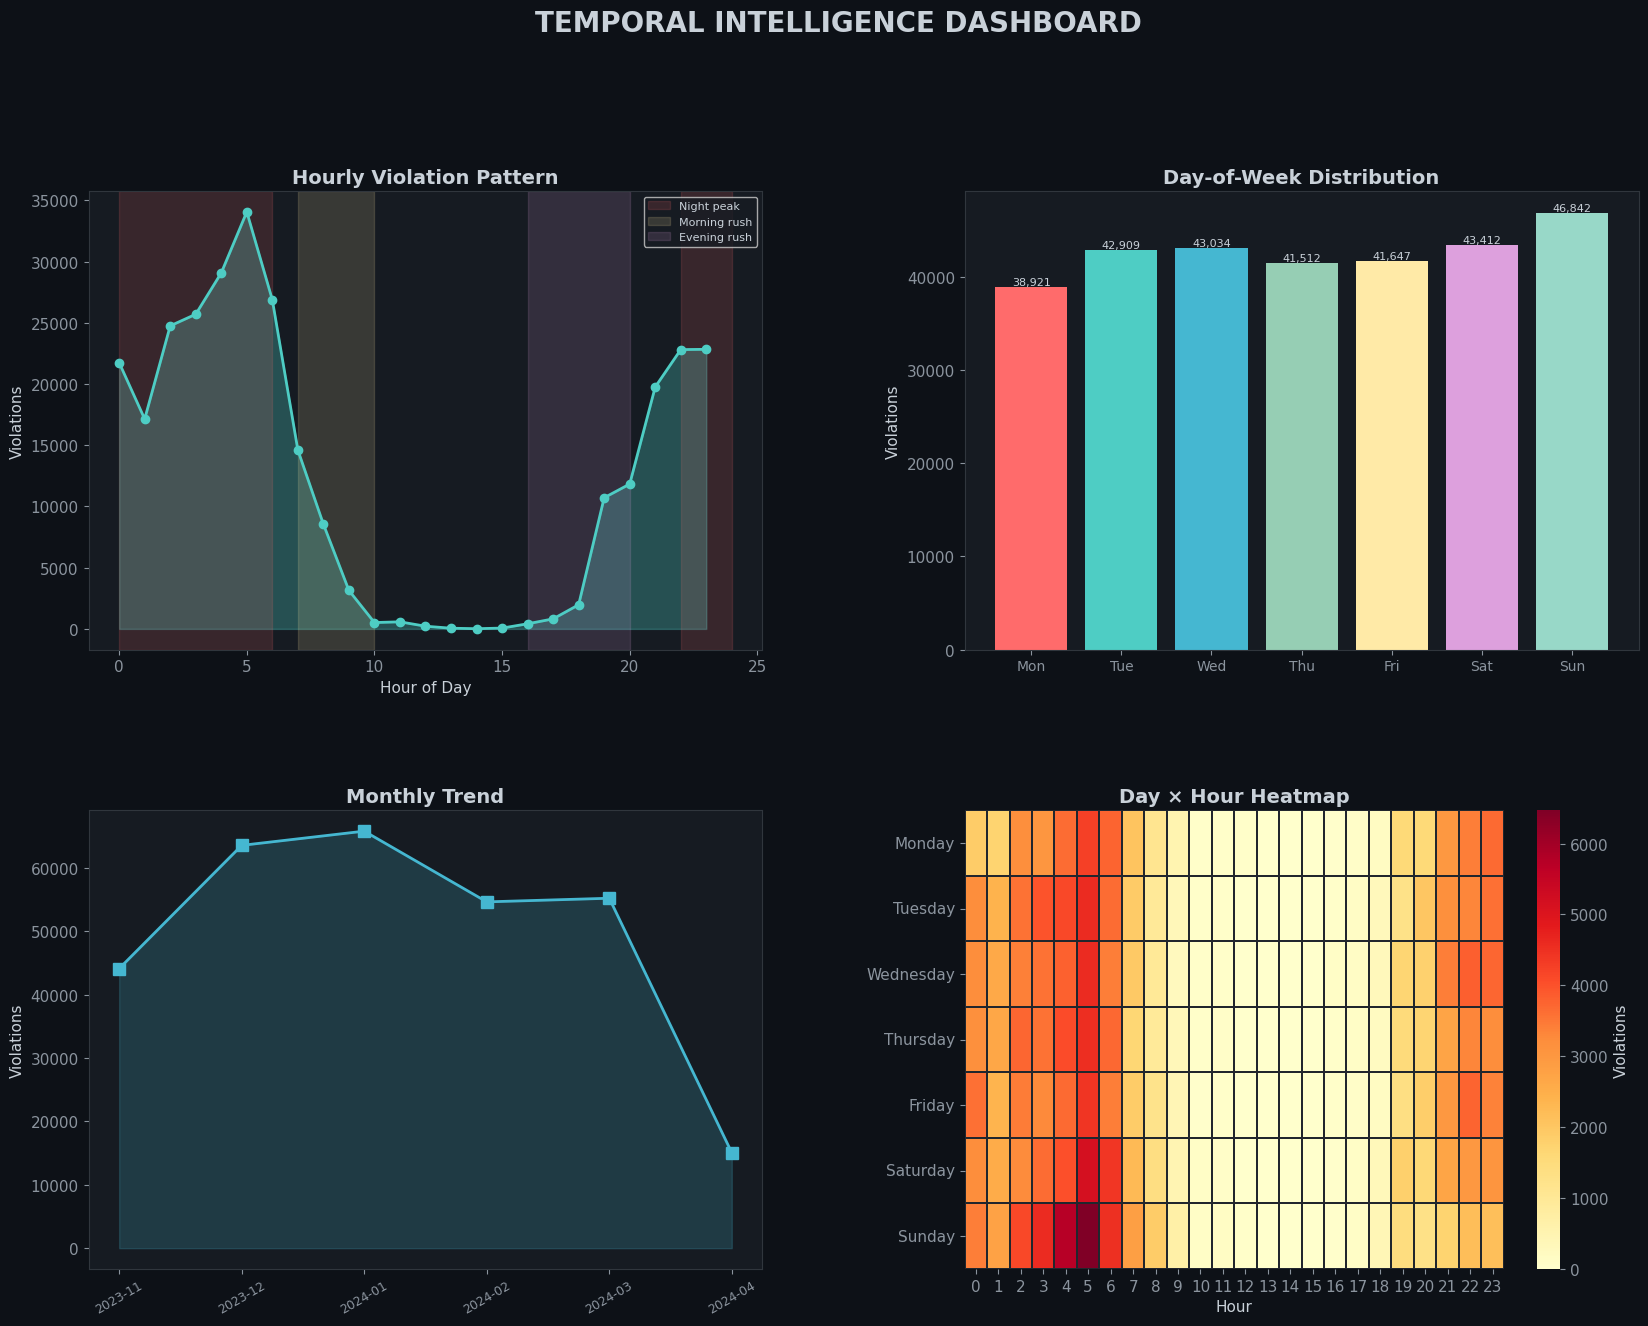

Section 2 complete: Temporal analysis saved


In [3]:
# --- Plot 4: 4-Panel Temporal Analysis ---
fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# Panel 1: Hourly Distribution
ax1 = fig.add_subplot(gs[0, 0])
hourly = df.groupby('hour').size()
ax1.fill_between(hourly.index, hourly.values, alpha=0.3, color='#4ECDC4')
ax1.plot(hourly.index, hourly.values, 'o-', color='#4ECDC4', linewidth=2, markersize=6)
ax1.set_title('Hourly Violation Pattern', fontweight='bold')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Violations')
ax1.axvspan(22, 24, alpha=0.15, color='#FF6B6B', label='Night peak')
ax1.axvspan(0, 6, alpha=0.15, color='#FF6B6B')
ax1.axvspan(7, 10, alpha=0.15, color='#FFEAA7', label='Morning rush')
ax1.axvspan(16, 20, alpha=0.15, color='#DDA0DD', label='Evening rush')
ax1.legend(fontsize=8)

# Panel 2: Day of Week
ax2 = fig.add_subplot(gs[0, 1])
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df['day_of_week'].value_counts().reindex(day_order)
bars = ax2.bar(range(len(daily)), daily.values, color=COLORS[:7])
ax2.set_xticks(range(len(daily)))
ax2.set_xticklabels([d[:3] for d in day_order], fontsize=10)
ax2.set_title('Day-of-Week Distribution', fontweight='bold')
ax2.set_ylabel('Violations')
for i, v in enumerate(daily.values):
    ax2.text(i, v + 200, f'{v:,}', ha='center', fontsize=8, color='#C9D1D9')

# Panel 3: Monthly Trend
ax3 = fig.add_subplot(gs[1, 0])
monthly = df.groupby('month').size().sort_index()
ax3.plot(range(len(monthly)), monthly.values, 's-', color='#45B7D1', linewidth=2, markersize=8)
ax3.fill_between(range(len(monthly)), monthly.values, alpha=0.2, color='#45B7D1')
ax3.set_xticks(range(len(monthly)))
ax3.set_xticklabels(monthly.index, rotation=30, fontsize=9)
ax3.set_title('Monthly Trend', fontweight='bold')
ax3.set_ylabel('Violations')

# Panel 4: Day x Hour Heatmap
ax4 = fig.add_subplot(gs[1, 1])
pivot = df.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0)
pivot = pivot.reindex(day_order)
sns.heatmap(pivot, cmap='YlOrRd', ax=ax4, linewidths=0.3, linecolor='#21262D',
            cbar_kws={'label': 'Violations'})
ax4.set_title('Day × Hour Heatmap', fontweight='bold')
ax4.set_ylabel('')
ax4.set_xlabel('Hour')

plt.suptitle('TEMPORAL INTELLIGENCE DASHBOARD', fontsize=20, fontweight='bold', y=1.01)
plt.savefig(f'../assets/images/analysis_charts/04_temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Section 2 complete: Temporal analysis saved')


---
## 🗺️ Section 3: Spatial Intelligence & HDBSCAN Clustering

Using HDBSCAN (Hierarchical Density-Based Spatial Clustering of Applications with Noise) to identify parking violation hotspot zones. HDBSCAN is chosen over K-Means because it:
- Does **not require pre-specifying K** (number of clusters)
- Handles **varying density** (Bengaluru CBD vs suburbs)
- Uses **haversine metric** for earth-surface distances
- Identifies **noise points** that don't belong to any cluster


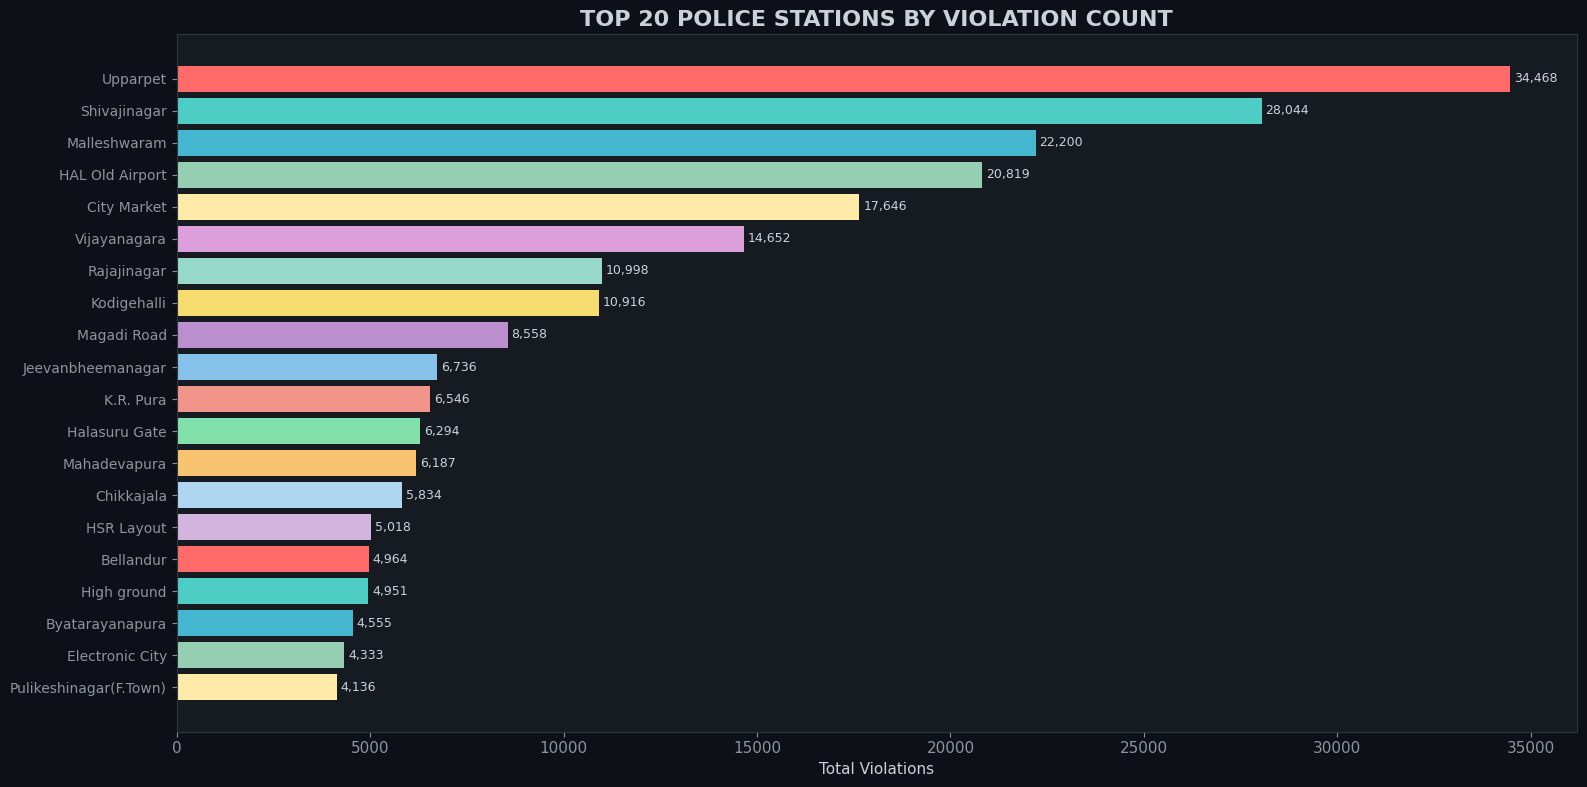

Running HDBSCAN clustering (this may take 30-60 seconds)...


HDBSCAN Results: 312 clusters found, 74,391 noise points (24.9%)


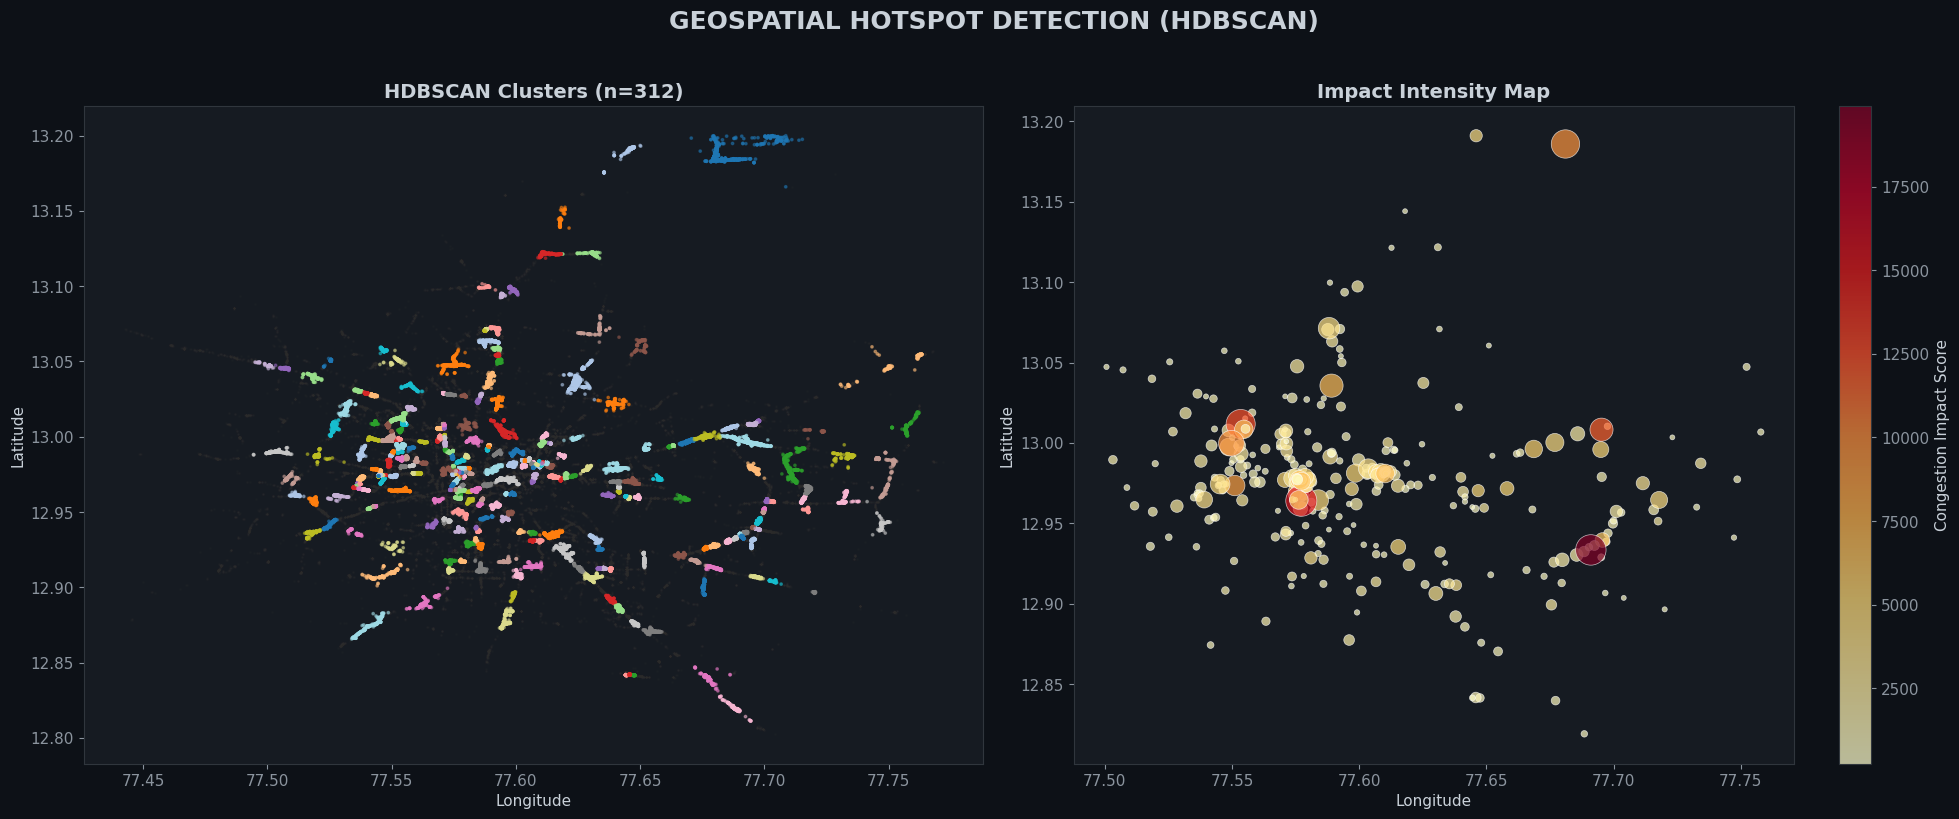

Section 3 complete: Spatial analysis + clustering saved


In [4]:
# --- Plot 5: Spatial Distribution by Police Station ---
fig, ax = plt.subplots(figsize=(16, 8))
if 'police_station' in df.columns:
    ps_counts = df['police_station'].value_counts().head(20)
    bars = ax.barh(range(len(ps_counts)), ps_counts.values, color=COLORS[:len(ps_counts)] * 2)
    ax.set_yticks(range(len(ps_counts)))
    ax.set_yticklabels(ps_counts.index, fontsize=10)
    for i, v in enumerate(ps_counts.values):
        ax.text(v + 100, i, f'{v:,}', va='center', fontsize=9, color='#C9D1D9')
    ax.invert_yaxis()
ax.set_title('TOP 20 POLICE STATIONS BY VIOLATION COUNT', fontsize=16, fontweight='bold')
ax.set_xlabel('Total Violations')
plt.tight_layout()
plt.savefig(f'../assets/images/analysis_charts/05_spatial_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# --- HDBSCAN Clustering ---
print('Running HDBSCAN clustering (this may take 30-60 seconds)...')
coords = df[['latitude', 'longitude']].values
coords_rad = np.radians(coords)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=150,
    metric='haversine',
    cluster_selection_method='eom',
    core_dist_n_jobs=-1
)
df['cluster'] = clusterer.fit_predict(coords_rad)

n_clusters = df['cluster'].max() + 1
n_noise = (df['cluster'] == -1).sum()
print(f'HDBSCAN Results: {n_clusters} clusters found, {n_noise:,} noise points ({n_noise/len(df)*100:.1f}%)')

# --- Plot 6: HDBSCAN Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Left: Colored scatter
clustered = df[df['cluster'] >= 0]
noise = df[df['cluster'] == -1]
axes[0].scatter(noise['longitude'], noise['latitude'], c='#333333', s=1, alpha=0.1, label='Noise')
scatter = axes[0].scatter(clustered['longitude'], clustered['latitude'],
    c=clustered['cluster'] % 20, cmap='tab20', s=3, alpha=0.5)
axes[0].set_title(f'HDBSCAN Clusters (n={n_clusters})', fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Right: Impact bubble map
zone_stats = df[df['cluster'] >= 0].groupby('cluster').agg(
    lat=('latitude', 'mean'), lon=('longitude', 'mean'),
    count=('record_impact', 'size'), impact=('record_impact', 'sum')
).reset_index()

scatter2 = axes[1].scatter(zone_stats['lon'], zone_stats['lat'],
    s=zone_stats['count'] / zone_stats['count'].max() * 500,
    c=zone_stats['impact'], cmap='YlOrRd', alpha=0.7, edgecolors='white', linewidth=0.5)
plt.colorbar(scatter2, ax=axes[1], label='Congestion Impact Score')
axes[1].set_title('Impact Intensity Map', fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('GEOSPATIAL HOTSPOT DETECTION (HDBSCAN)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'../assets/images/analysis_charts/06_hdbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Section 3 complete: Spatial analysis + clustering saved')


---
## 🏆 Section 4: Priority Zone Ranking & Enforcement Scheduling

Scoring each hotspot zone with a composite **Congestion Impact Score** and generating per-zone patrol schedules.


Saved priority ranking for 312 zones


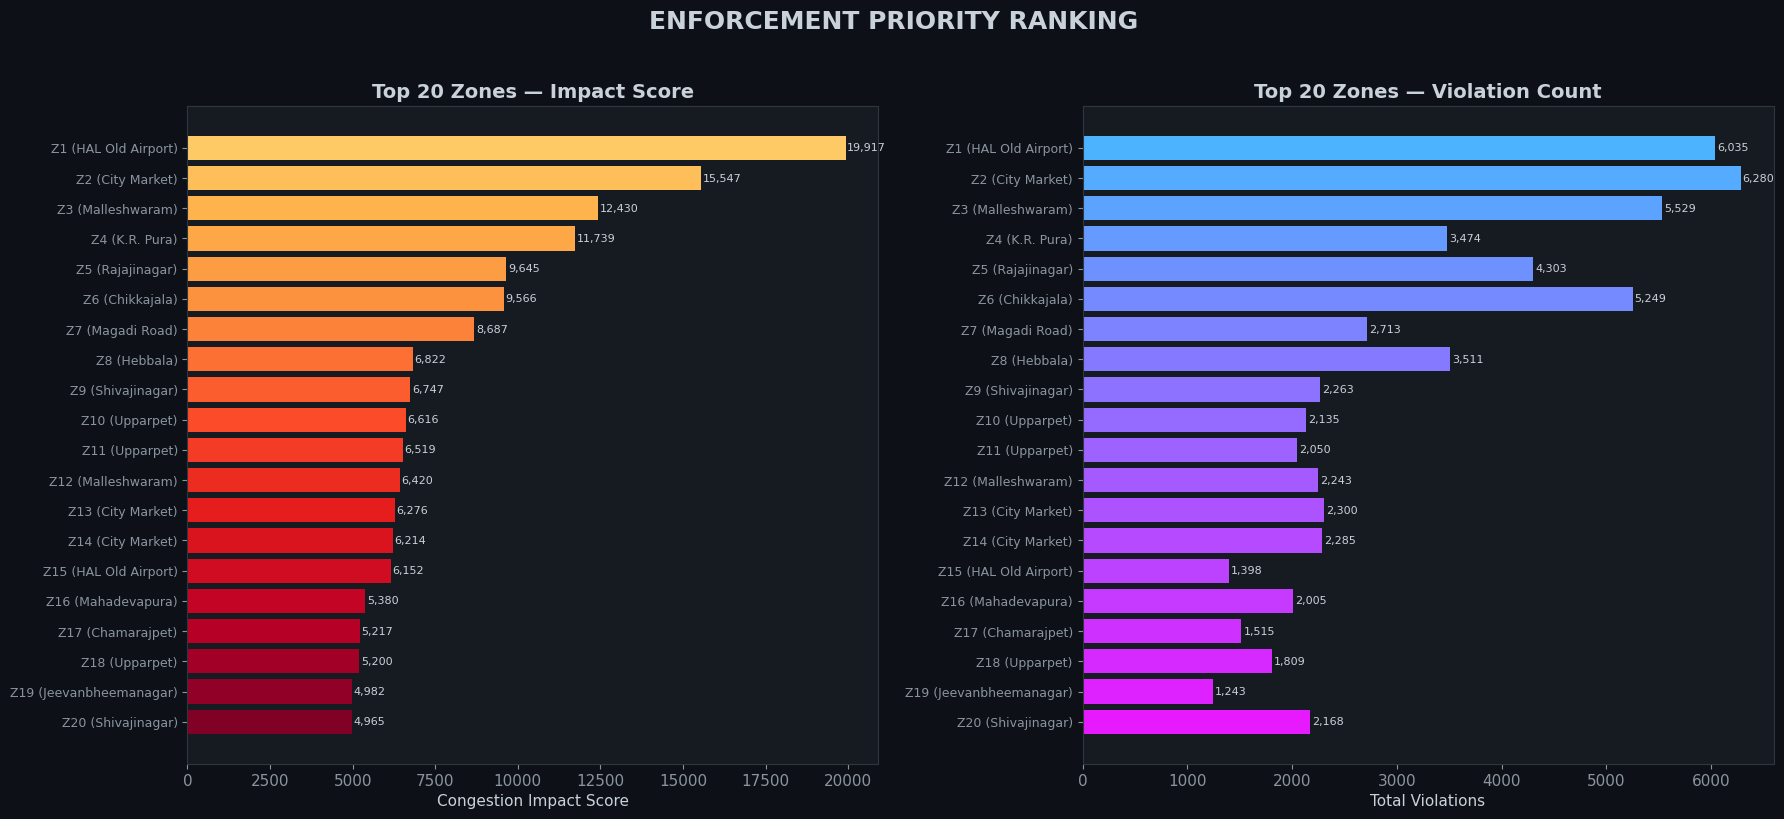

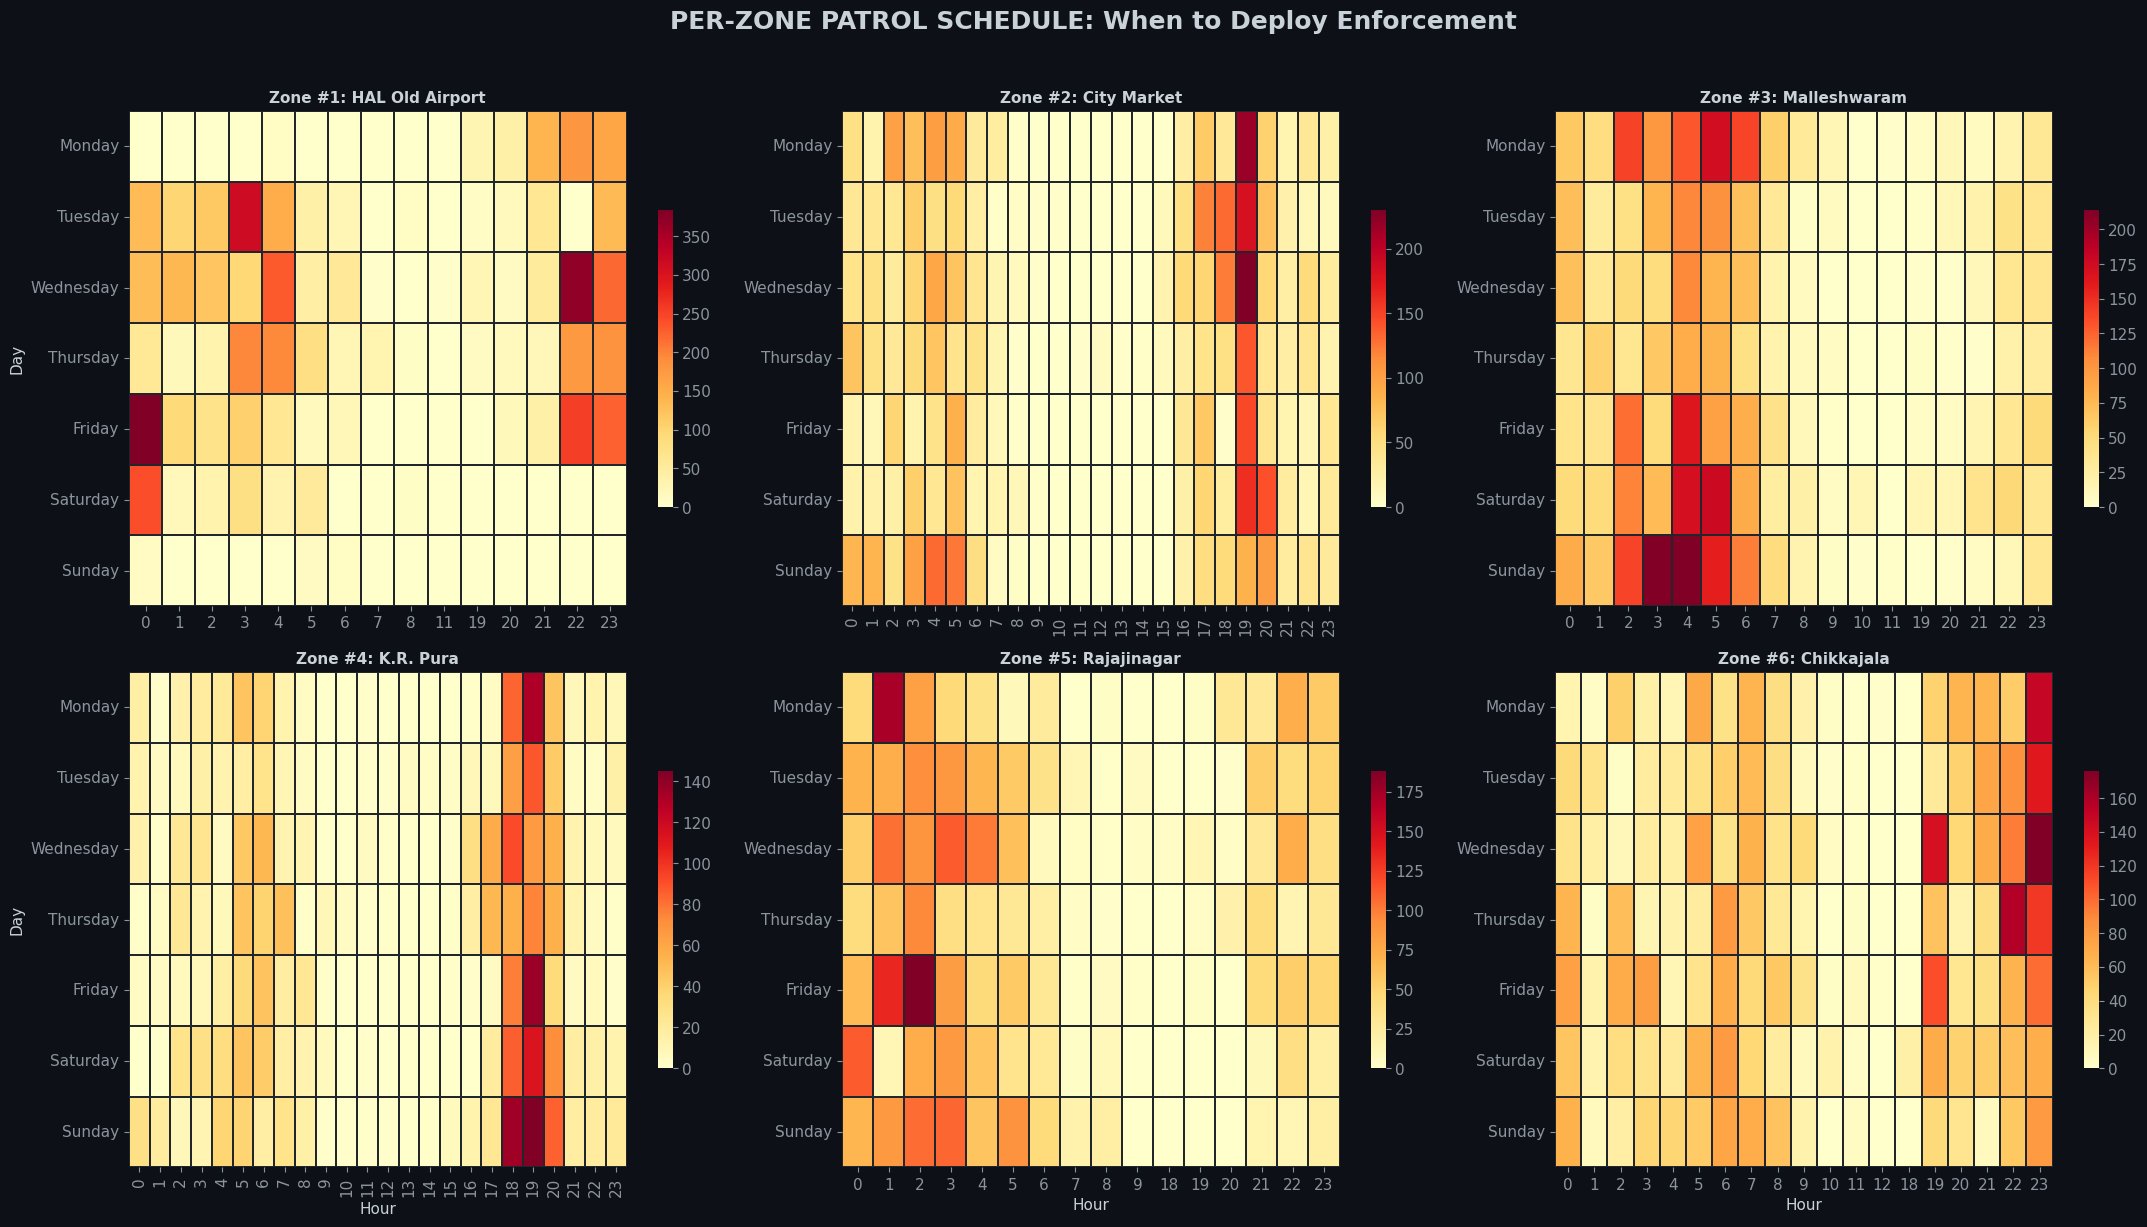

Chronic offenders (11+ violations): 552
Worst offender: 55 violations


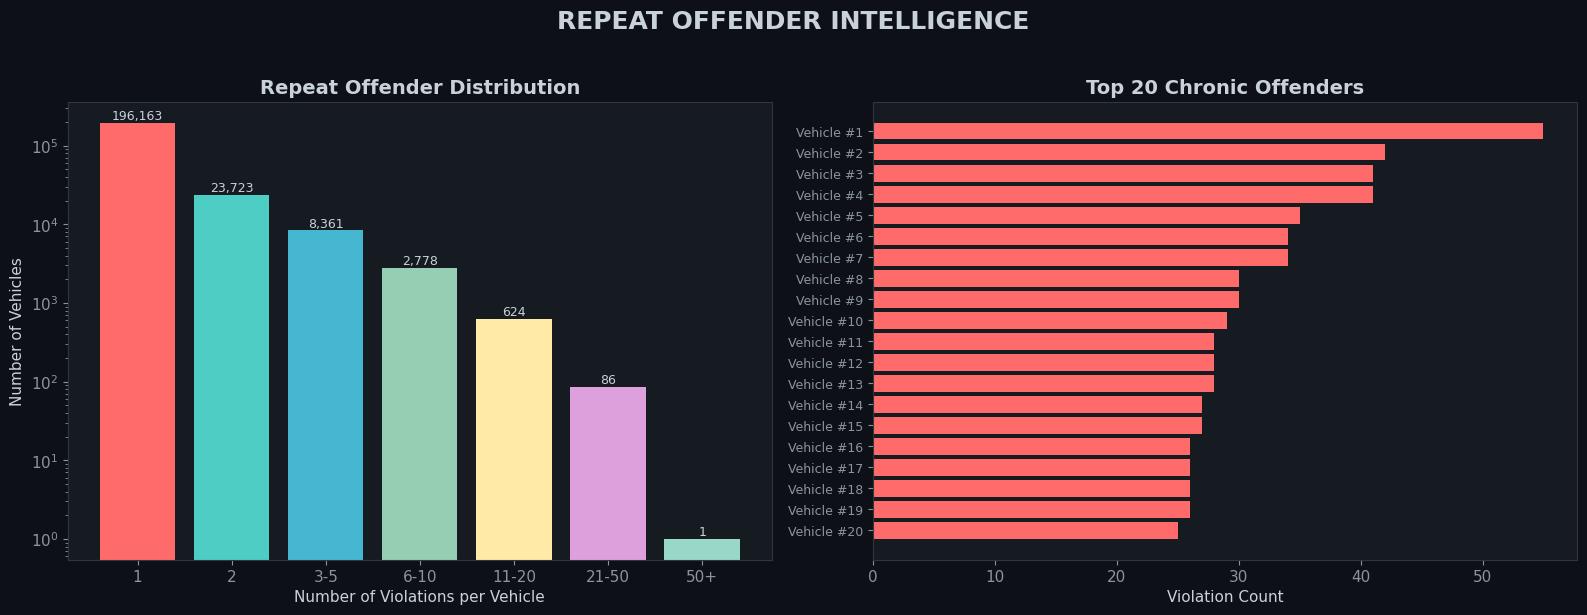

Section 4 complete: Priority ranking, patrol schedules, repeat offenders saved


In [5]:
# --- Build Zone Rankings ---
zone_data = df[df['cluster'] >= 0].copy()

# Get police station for each zone
if 'police_station' in zone_data.columns:
    zone_ps = zone_data.groupby('cluster')['police_station'].agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'Unknown')
else:
    zone_ps = pd.Series('Unknown', index=range(n_clusters))

zone_rankings = zone_data.groupby('cluster').agg(
    total_violations=('record_impact', 'size'),
    congestion_impact_score=('record_impact', 'sum'),
    mean_severity=('severity_weight', 'mean'),
    center_lat=('latitude', 'mean'),
    center_lon=('longitude', 'mean'),
    unique_vehicles=('vehicle_number' if 'vehicle_number' in df.columns else 'latitude', 'nunique'),
    top_violation=('violation_type', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'Unknown'),
    top_vehicle=('vehicle_type', lambda x: x.mode().iloc[0] if 'vehicle_type' in x.name or True else 'Unknown') if 'vehicle_type' in df.columns else ('latitude', 'size'),
    night_pct=('hour', lambda x: ((x < 6) | (x >= 22)).mean() * 100),
    peak_hour=('hour', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 0)
).sort_values('congestion_impact_score', ascending=False).reset_index()

# Fix top_vehicle if it wasn't computed correctly
if 'vehicle_type' in df.columns:
    zone_rankings['top_vehicle'] = zone_data.groupby('cluster')['vehicle_type'].agg(
        lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'Unknown').values[zone_rankings['cluster'].values] if len(zone_rankings) > 0 else 'Unknown'

zone_rankings['police_station'] = zone_rankings['cluster'].map(zone_ps)
zone_rankings['rank'] = range(1, len(zone_rankings) + 1)

# Save CSV
zone_rankings.to_csv(f'{OUTPUT_DIR}/enforcement_priority_ranking.csv', index=False)
print(f'Saved priority ranking for {len(zone_rankings)} zones')

# --- Plot 7: Top 20 Priority Zones ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
top20 = zone_rankings.head(20)
labels = [f'Z{r} ({ps})' for r, ps in zip(top20['rank'], top20['police_station'])]

bars = axes[0].barh(range(len(top20)), top20['congestion_impact_score'].values,
    color=plt.cm.YlOrRd(np.linspace(0.3, 1.0, len(top20))))
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(labels, fontsize=9)
axes[0].set_xlabel('Congestion Impact Score')
axes[0].set_title('Top 20 Zones — Impact Score', fontweight='bold')
axes[0].invert_yaxis()
for i, v in enumerate(top20['congestion_impact_score'].values):
    axes[0].text(v + 50, i, f'{v:,.0f}', va='center', fontsize=8, color='#C9D1D9')

axes[1].barh(range(len(top20)), top20['total_violations'].values,
    color=plt.cm.cool(np.linspace(0.3, 0.9, len(top20))))
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(labels, fontsize=9)
axes[1].set_xlabel('Total Violations')
axes[1].set_title('Top 20 Zones — Violation Count', fontweight='bold')
axes[1].invert_yaxis()
for i, v in enumerate(top20['total_violations'].values):
    axes[1].text(v + 20, i, f'{v:,}', va='center', fontsize=8, color='#C9D1D9')

plt.suptitle('ENFORCEMENT PRIORITY RANKING', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'../assets/images/analysis_charts/07_priority_zones.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 8: Per-Zone Temporal Heatmaps (Top 6) ---
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
top6_clusters = zone_rankings.head(6)['cluster'].values

for idx, (ax, clust) in enumerate(zip(axes.flatten(), top6_clusters)):
    zone = df[df['cluster'] == clust]
    pivot = zone.groupby(['day_of_week', 'hour']).size().unstack(fill_value=0).reindex(day_order)
    sns.heatmap(pivot, cmap='YlOrRd', ax=ax, cbar=True, linewidths=0.2, linecolor='#21262D',
                cbar_kws={'shrink': 0.6})
    ps = zone_rankings[zone_rankings['cluster'] == clust]['police_station'].values[0]
    ax.set_title(f'Zone #{idx+1}: {ps}', fontweight='bold', fontsize=11)
    ax.set_ylabel('' if idx % 3 != 0 else 'Day')
    ax.set_xlabel('Hour' if idx >= 3 else '')

plt.suptitle('PER-ZONE PATROL SCHEDULE: When to Deploy Enforcement', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'../assets/images/analysis_charts/08_temporal_per_zone.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 9: Repeat Offender Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
if 'vehicle_number' in df.columns:
    veh_counts = df['vehicle_number'].value_counts()
    bins = [1, 2, 3, 5, 10, 20, 50, 100]
    labels_b = ['1', '2', '3-5', '6-10', '11-20', '21-50', '50+']
    veh_binned = pd.cut(veh_counts, bins=bins, labels=labels_b, right=False).value_counts().sort_index()
    axes[0].bar(range(len(veh_binned)), veh_binned.values, color=COLORS[:len(veh_binned)])
    axes[0].set_xticks(range(len(veh_binned)))
    axes[0].set_xticklabels(labels_b)
    axes[0].set_xlabel('Number of Violations per Vehicle')
    axes[0].set_ylabel('Number of Vehicles')
    axes[0].set_title('Repeat Offender Distribution', fontweight='bold')
    axes[0].set_yscale('log')
    for i, v in enumerate(veh_binned.values):
        axes[0].text(i, v * 1.1, f'{v:,}', ha='center', fontsize=9, color='#C9D1D9')

    top_offenders = veh_counts.head(20)
    axes[1].barh(range(len(top_offenders)), top_offenders.values, color='#FF6B6B')
    axes[1].set_yticks(range(len(top_offenders)))
    axes[1].set_yticklabels([f'Vehicle #{i+1}' for i in range(len(top_offenders))], fontsize=9)
    axes[1].set_xlabel('Violation Count')
    axes[1].set_title('Top 20 Chronic Offenders', fontweight='bold')
    axes[1].invert_yaxis()

    n_chronic = (veh_counts >= 11).sum()
    max_v = veh_counts.max()
    print(f'Chronic offenders (11+ violations): {n_chronic}')
    print(f'Worst offender: {max_v} violations')

plt.suptitle('REPEAT OFFENDER INTELLIGENCE', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'../assets/images/analysis_charts/09_repeat_offenders.png', dpi=150, bbox_inches='tight')
plt.show()
print('Section 4 complete: Priority ranking, patrol schedules, repeat offenders saved')


---
## 🚀 Section 5: Advanced Analytics & Enhancements

Five advanced analytical layers that go beyond basic hotspot detection:
1. **Enforcement ROI Simulation** — What-if analysis for deployment
2. **Economic Cost Estimation** — Congestion cost in ₹/month  
3. **Vehicle-Specific Strategy** — Tailored enforcement by vehicle type
4. **Anomaly Detection** — Z-score time-series analysis
5. **Zone Risk Profile Cards** — Executive-ready intelligence cards


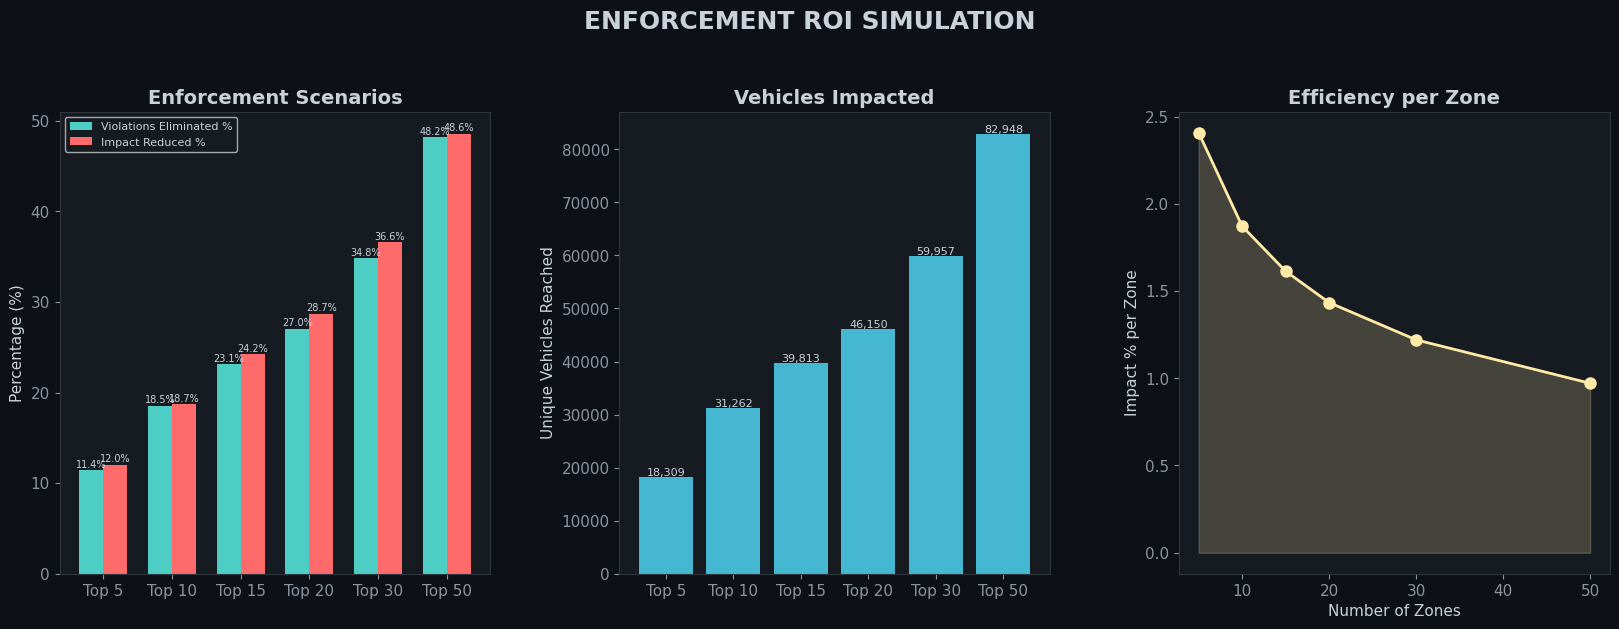

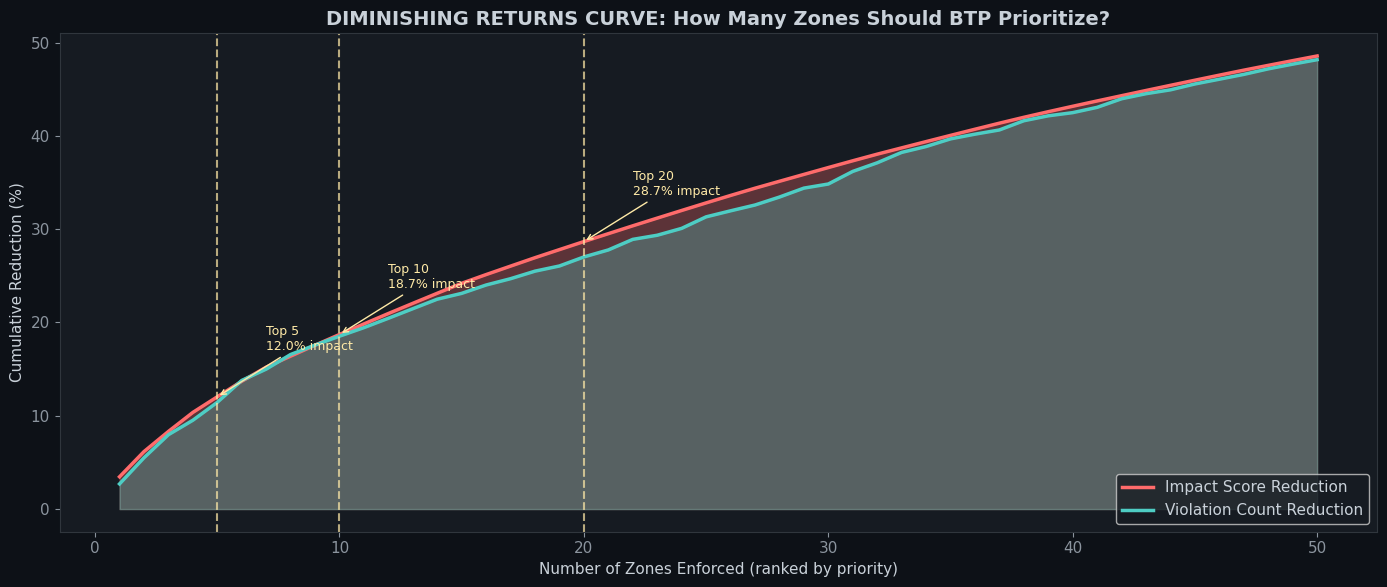

Enhancement 1 complete: ROI simulation saved


In [6]:
# --- Enhancement 1: Enforcement ROI Simulation ---
scenarios = [5, 10, 15, 20, 30, 50]
total_violations = len(zone_data)
total_impact = zone_data['record_impact'].sum()
total_vehicles = zone_data['vehicle_number'].nunique() if 'vehicle_number' in zone_data.columns else 0

results = []
for n in scenarios:
    top_n = zone_rankings.head(n)['cluster'].values
    affected = zone_data[zone_data['cluster'].isin(top_n)]
    v_pct = len(affected) / total_violations * 100
    i_pct = affected['record_impact'].sum() / total_impact * 100
    uv = affected['vehicle_number'].nunique() if 'vehicle_number' in affected.columns else 0
    results.append({'zones': n, 'violation_pct': v_pct, 'impact_pct': i_pct, 'vehicles': uv})

roi_df = pd.DataFrame(results)

# --- Plot 10: ROI Simulation ---
fig = plt.figure(figsize=(20, 6))
gs = gridspec.GridSpec(1, 3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
x = range(len(roi_df))
w = 0.35
ax1.bar([i - w/2 for i in x], roi_df['violation_pct'], w, color='#4ECDC4', label='Violations Eliminated %')
ax1.bar([i + w/2 for i in x], roi_df['impact_pct'], w, color='#FF6B6B', label='Impact Reduced %')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Top {n}' for n in scenarios])
ax1.set_ylabel('Percentage (%)')
ax1.set_title('Enforcement Scenarios', fontweight='bold')
ax1.legend(fontsize=8)
for i, row in roi_df.iterrows():
    ax1.text(i - w/2, row['violation_pct'] + 0.3, f'{row["violation_pct"]:.1f}%', ha='center', fontsize=7, color='#C9D1D9')
    ax1.text(i + w/2, row['impact_pct'] + 0.3, f'{row["impact_pct"]:.1f}%', ha='center', fontsize=7, color='#C9D1D9')

ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(x, roi_df['vehicles'], color='#45B7D1')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Top {n}' for n in scenarios])
ax2.set_ylabel('Unique Vehicles Reached')
ax2.set_title('Vehicles Impacted', fontweight='bold')
for i, v in enumerate(roi_df['vehicles']):
    ax2.text(i, v + 200, f'{v:,}', ha='center', fontsize=8, color='#C9D1D9')

ax3 = fig.add_subplot(gs[0, 2])
efficiency = roi_df['impact_pct'] / roi_df['zones']
ax3.plot(roi_df['zones'], efficiency, 'o-', color='#FFEAA7', linewidth=2, markersize=8)
ax3.fill_between(roi_df['zones'], efficiency, alpha=0.2, color='#FFEAA7')
ax3.set_xlabel('Number of Zones')
ax3.set_ylabel('Impact % per Zone')
ax3.set_title('Efficiency per Zone', fontweight='bold')

plt.suptitle('ENFORCEMENT ROI SIMULATION', fontsize=18, fontweight='bold', y=1.05)
plt.savefig(f'../assets/images/analysis_charts/10_enforcement_roi.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 11: Diminishing Returns Curve ---
fig, ax = plt.subplots(figsize=(14, 6))
cum_violations = []
cum_impact = []
for n in range(1, min(51, len(zone_rankings) + 1)):
    top_n_clusters = zone_rankings.head(n)['cluster'].values
    affected = zone_data[zone_data['cluster'].isin(top_n_clusters)]
    cum_violations.append(len(affected) / total_violations * 100)
    cum_impact.append(affected['record_impact'].sum() / total_impact * 100)

x_range = range(1, len(cum_violations) + 1)
ax.fill_between(x_range, cum_impact, alpha=0.3, color='#FF6B6B')
ax.fill_between(x_range, cum_violations, alpha=0.3, color='#4ECDC4')
ax.plot(x_range, cum_impact, '-', color='#FF6B6B', linewidth=2.5, label='Impact Score Reduction')
ax.plot(x_range, cum_violations, '-', color='#4ECDC4', linewidth=2.5, label='Violation Count Reduction')

for n, label_n in [(5, 'Top 5'), (10, 'Top 10'), (20, 'Top 20')]:
    if n <= len(cum_impact):
        ax.axvline(x=n, color='#FFEAA7', linestyle='--', alpha=0.7)
        ax.annotate(f'{label_n}\n{cum_impact[n-1]:.1f}% impact', xy=(n, cum_impact[n-1]),
                   xytext=(n+2, cum_impact[n-1]+5), fontsize=9, color='#FFEAA7',
                   arrowprops=dict(arrowstyle='->', color='#FFEAA7'))

ax.set_xlabel('Number of Zones Enforced (ranked by priority)')
ax.set_ylabel('Cumulative Reduction (%)')
ax.set_title('DIMINISHING RETURNS CURVE: How Many Zones Should BTP Prioritize?', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'../assets/images/analysis_charts/11_diminishing_returns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Enhancement 1 complete: ROI simulation saved')


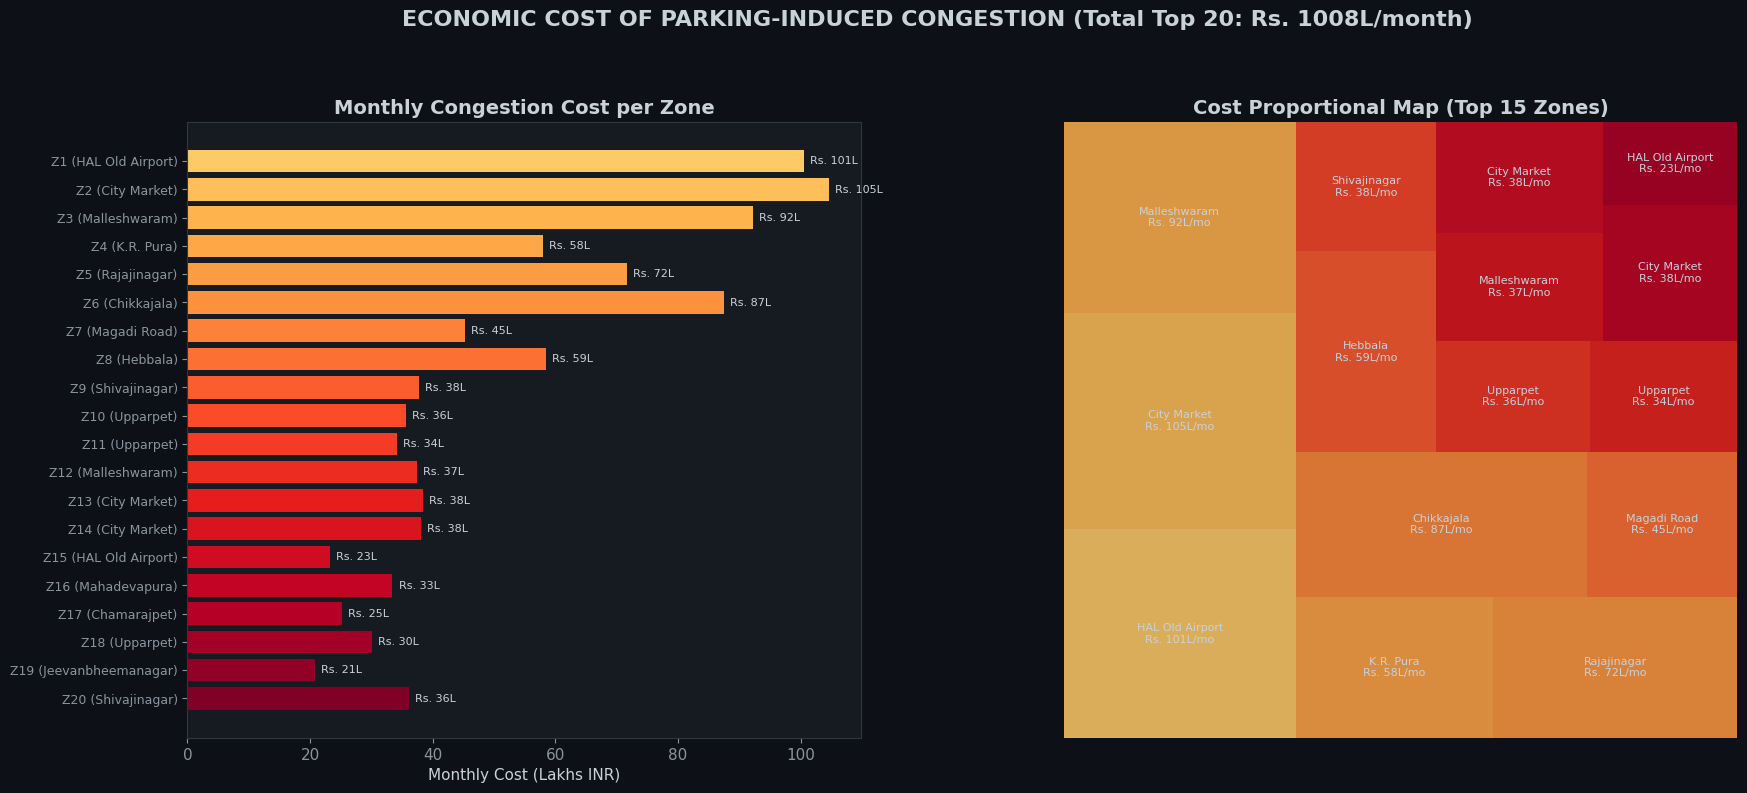

Enhancement 2 complete: Total monthly cost (Top 20): Rs. 1008 Lakhs


In [7]:
# --- Enhancement 2: Economic Cost Estimation ---
DELAY_MINUTES = 15
TIME_VALUE_PER_HOUR = 200  # INR
VEHICLES_AFFECTED_PER_VIOLATION_HR = 50
AVG_PARKING_DURATION_HRS = 4

cost_per_violation = (DELAY_MINUTES / 60) * TIME_VALUE_PER_HOUR * VEHICLES_AFFECTED_PER_VIOLATION_HR * AVG_PARKING_DURATION_HRS
months_in_data = max(df['month'].nunique(), 1)

top20 = zone_rankings.head(20).copy()
top20['monthly_violations'] = top20['total_violations'] / months_in_data
top20['monthly_cost_lakhs'] = (top20['monthly_violations'] * cost_per_violation) / 100000

# --- Plot 12: Economic Cost ---
fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
labels = [f'Z{r} ({ps})' for r, ps in zip(top20['rank'], top20['police_station'])]
colors_grad = plt.cm.YlOrRd(np.linspace(0.3, 1.0, len(top20)))
bars = ax1.barh(range(len(top20)), top20['monthly_cost_lakhs'].values, color=colors_grad)
ax1.set_yticks(range(len(top20)))
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_xlabel('Monthly Cost (Lakhs INR)')
ax1.set_title('Monthly Congestion Cost per Zone', fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(top20['monthly_cost_lakhs'].values):
    ax1.text(v + 1, i, f'Rs. {v:.0f}L', va='center', fontsize=8, color='#C9D1D9')

ax2 = fig.add_subplot(gs[0, 1])
top15_cost = top20.head(15)
sizes = top15_cost['monthly_cost_lakhs'].values
treemap_labels = [f"{ps}\nRs. {c:.0f}L/mo" for ps, c in zip(top15_cost['police_station'], sizes)]
treemap_colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(sizes)))
squarify.plot(sizes=sizes, label=treemap_labels, color=treemap_colors, alpha=0.85,
              text_kwargs={'fontsize': 8, 'color': '#C9D1D9'}, ax=ax2)
ax2.set_title('Cost Proportional Map (Top 15 Zones)', fontweight='bold')
ax2.axis('off')

total_monthly = top20['monthly_cost_lakhs'].sum()
plt.suptitle(f'ECONOMIC COST OF PARKING-INDUCED CONGESTION (Total Top 20: Rs. {total_monthly:.0f}L/month)',
             fontsize=16, fontweight='bold', y=1.02)
plt.savefig(f'../assets/images/analysis_charts/12_economic_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Enhancement 2 complete: Total monthly cost (Top 20): Rs. {total_monthly:.0f} Lakhs')


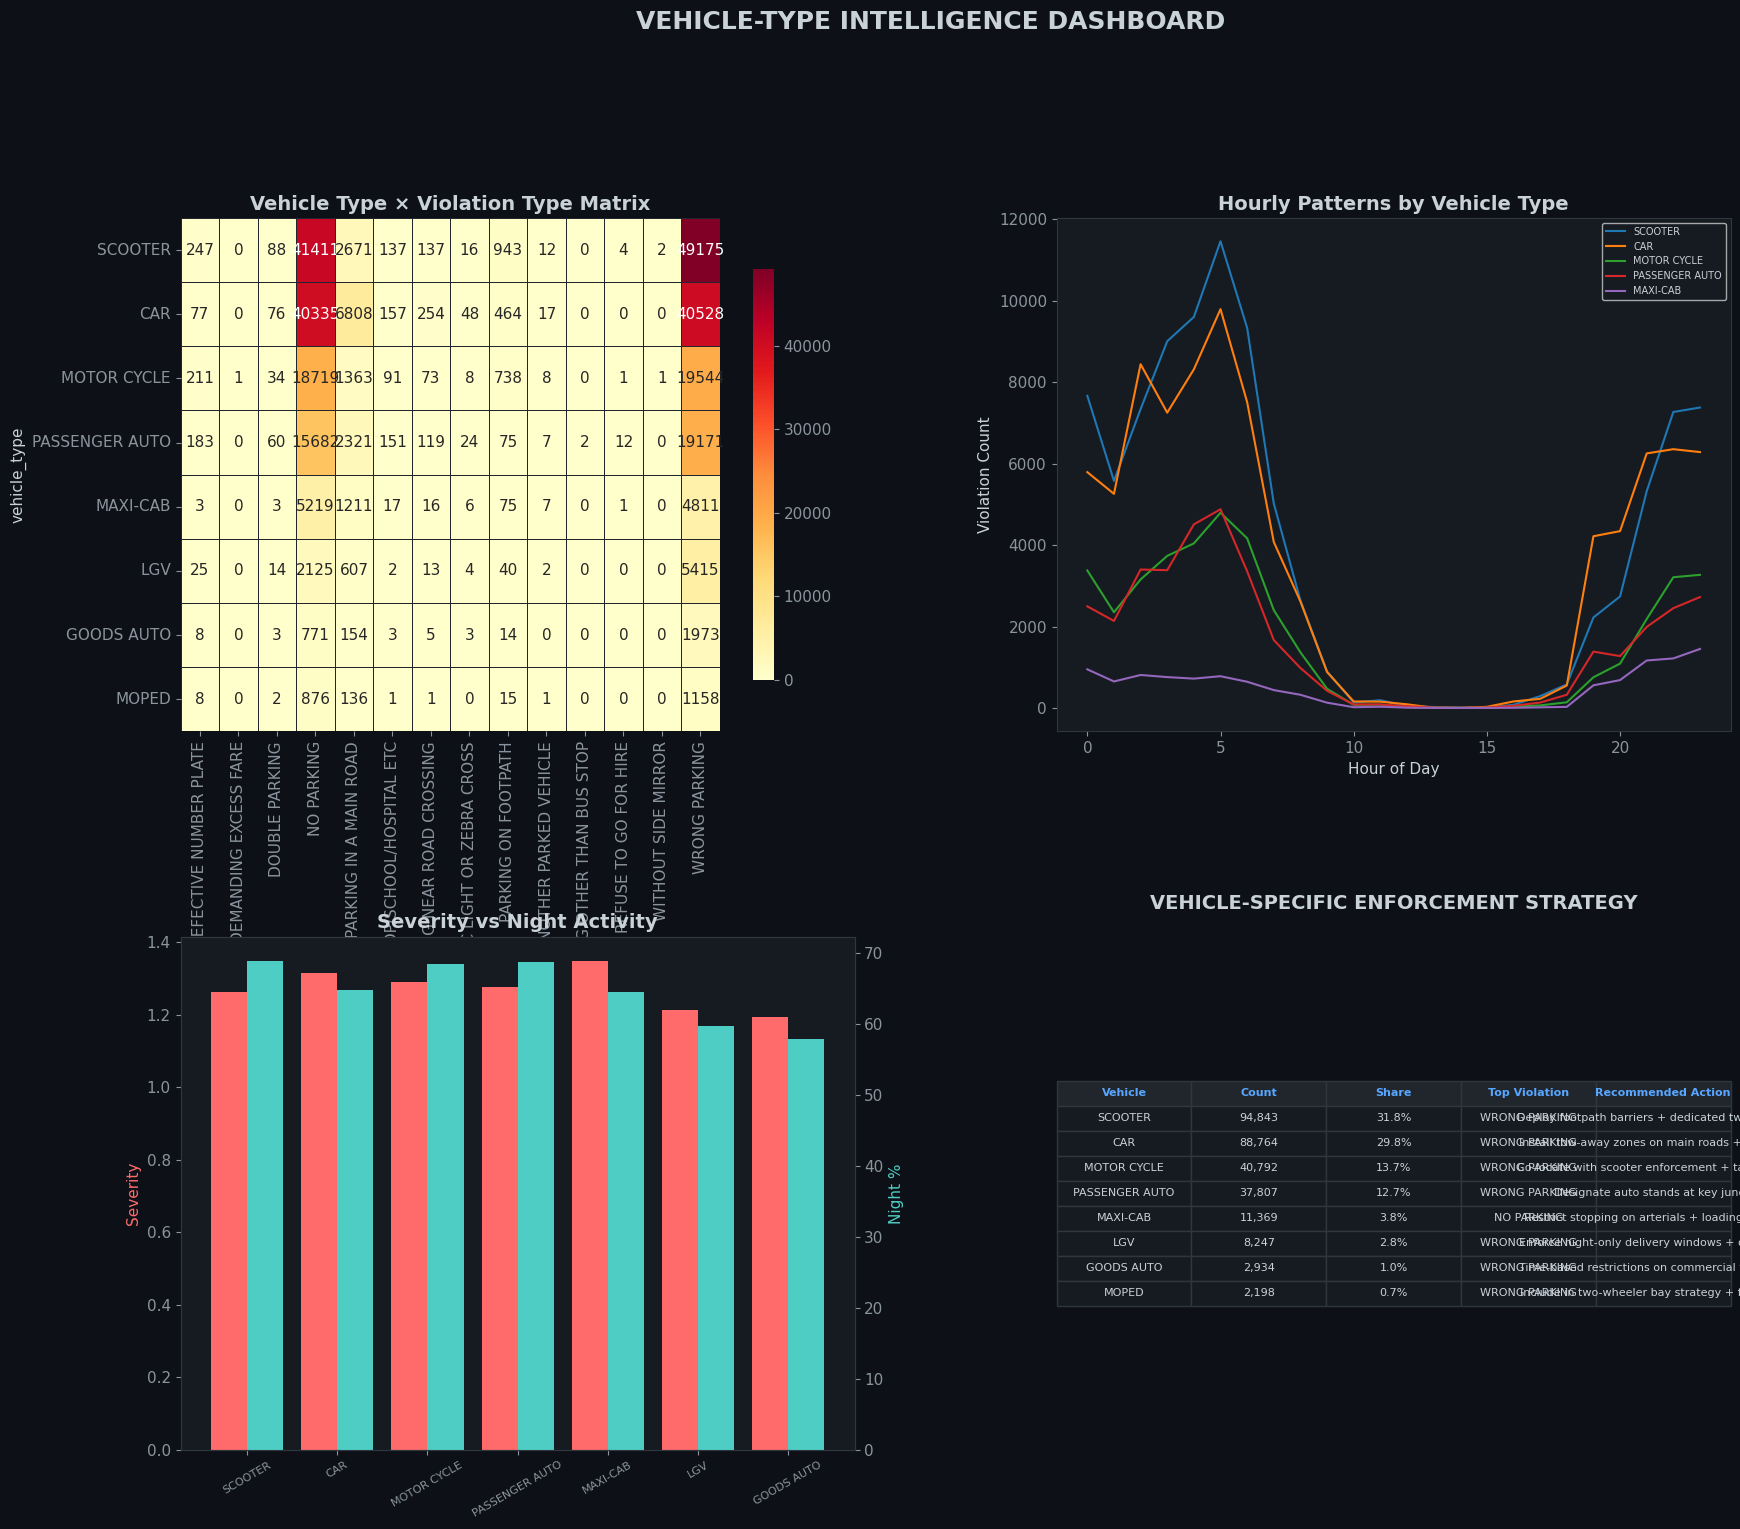

Enhancement 3 complete: Vehicle strategy dashboard saved


In [8]:
# --- Enhancement 3: Vehicle-Specific Enforcement Strategy ---
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.3)

if 'vehicle_type' in df.columns:
    vt_top = df['vehicle_type'].value_counts().head(8).index.tolist()
    df_vt = df[df['vehicle_type'].isin(vt_top)]

    # Panel 1: Vehicle × Violation Heatmap
    ax1 = fig.add_subplot(gs[0, 0])
    cross = pd.crosstab(df_vt['vehicle_type'], df_vt['violation_type'])
    cross = cross.reindex(index=vt_top)
    sns.heatmap(cross, cmap='YlOrRd', annot=True, fmt='d', ax=ax1,
                linewidths=0.5, linecolor='#21262D', cbar_kws={'shrink': 0.8})
    ax1.set_title('Vehicle Type × Violation Type Matrix', fontweight='bold')

    # Panel 2: Hourly by Vehicle Type
    ax2 = fig.add_subplot(gs[0, 1])
    for vt in vt_top[:5]:
        hourly_vt = df_vt[df_vt['vehicle_type'] == vt].groupby('hour').size()
        ax2.plot(hourly_vt.index, hourly_vt.values, '-', linewidth=1.5, label=vt)
    ax2.set_xlabel('Hour of Day')
    ax2.set_ylabel('Violation Count')
    ax2.set_title('Hourly Patterns by Vehicle Type', fontweight='bold')
    ax2.legend(fontsize=7)

    # Panel 3: Severity × Night Activity
    ax3 = fig.add_subplot(gs[1, 0])
    vt_stats = df_vt.groupby('vehicle_type').agg(
        severity=('severity_weight', 'mean'),
        night_pct=('hour', lambda x: ((x < 6) | (x >= 22)).mean() * 100)
    ).reindex(vt_top[:7])
    x_pos = range(len(vt_stats))
    ax3.bar([i - 0.2 for i in x_pos], vt_stats['severity'], 0.4, color='#FF6B6B', label='Severity')
    ax3_twin = ax3.twinx()
    ax3_twin.bar([i + 0.2 for i in x_pos], vt_stats['night_pct'], 0.4, color='#4ECDC4', label='Night %')
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels(vt_stats.index, rotation=30, fontsize=8)
    ax3.set_ylabel('Severity', color='#FF6B6B')
    ax3_twin.set_ylabel('Night %', color='#4ECDC4')
    ax3.set_title('Severity vs Night Activity', fontweight='bold')

    # Panel 4: Strategy Table
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.axis('off')
    strategies = {
        'SCOOTER': 'Deploy footpath barriers + dedicated two-wheeler bays',
        'CAR': 'Install tow-away zones on main roads + paid parking',
        'MOTOR CYCLE': 'Co-locate with scooter enforcement + targeted night patrols',
        'PASSENGER AUTO': 'Designate auto stands at key junctions',
        'MAXI-CAB': 'Restrict stopping on arterials + loading/unloading zones',
        'LGV': 'Enforce night-only delivery windows + designated loading bays',
        'GOODS AUTO': 'Time-based restrictions on commercial vehicle parking',
        'MOPED': 'Include in two-wheeler bay strategy + footpath enforcement'
    }
    table_data = []
    for vt in vt_top:
        vc = df[df['vehicle_type'] == vt]
        count = len(vc)
        share = f'{count/len(df)*100:.1f}%'
        top_v = vc['violation_type'].mode().iloc[0] if len(vc) > 0 else 'N/A'
        action = strategies.get(vt.upper(), 'General enforcement')
        table_data.append([vt, f'{count:,}', share, top_v, action[:50]])

    table = ax4.table(cellText=table_data,
                      colLabels=['Vehicle', 'Count', 'Share', 'Top Violation', 'Recommended Action'],
                      loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.5)
    for key, cell in table.get_celld().items():
        cell.set_facecolor('#161B22')
        cell.set_edgecolor('#30363D')
        cell.set_text_props(color='#C9D1D9')
        if key[0] == 0:
            cell.set_facecolor('#21262D')
            cell.set_text_props(fontweight='bold', color='#58A6FF')
    ax4.set_title('VEHICLE-SPECIFIC ENFORCEMENT STRATEGY', fontweight='bold', pad=20)

plt.suptitle('VEHICLE-TYPE INTELLIGENCE DASHBOARD', fontsize=18, fontweight='bold', y=1.01)
plt.savefig(f'../assets/images/analysis_charts/13_vehicle_strategy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Enhancement 3 complete: Vehicle strategy dashboard saved')


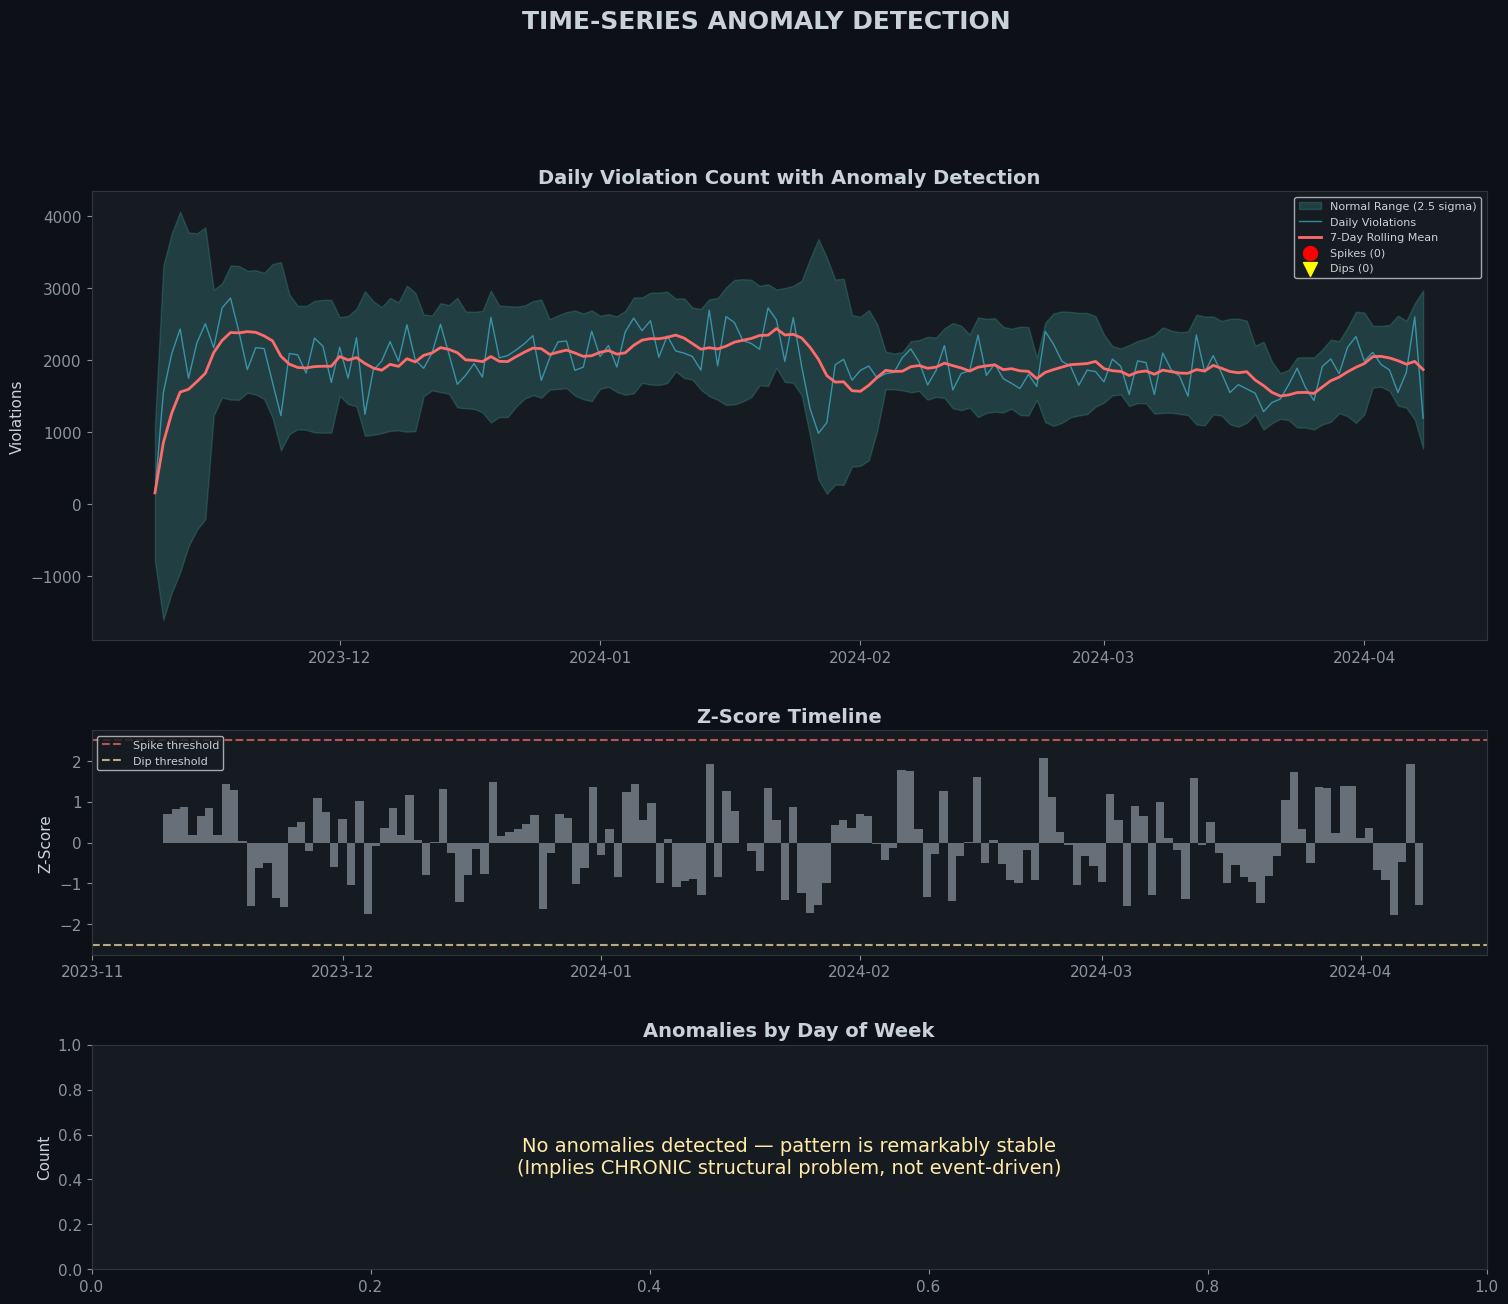

Enhancement 4 complete: 0 spikes, 0 dips detected
KEY FINDING: Zero anomalies = parking problem is STRUCTURAL & CHRONIC, not event-driven


In [9]:
# --- Enhancement 4: Time-Series Anomaly Detection ---
daily_counts = df.groupby('date').size().reset_index(name='count')
daily_counts['date'] = pd.to_datetime(daily_counts['date'])
daily_counts = daily_counts.sort_values('date').reset_index(drop=True)
daily_counts['rolling_mean'] = daily_counts['count'].rolling(7, min_periods=1).mean()
daily_counts['rolling_std'] = daily_counts['count'].rolling(7, min_periods=1).std().fillna(daily_counts['count'].std())
daily_counts['z_score'] = (daily_counts['count'] - daily_counts['rolling_mean']) / daily_counts['rolling_std'].replace(0, 1)

THRESHOLD = 2.5
daily_counts['is_spike'] = daily_counts['z_score'] > THRESHOLD
daily_counts['is_dip'] = daily_counts['z_score'] < -THRESHOLD

fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 1, height_ratios=[2, 1, 1], hspace=0.3)

# Panel 1: Daily violations with anomaly bands
ax1 = fig.add_subplot(gs[0])
ax1.fill_between(daily_counts['date'],
    daily_counts['rolling_mean'] - THRESHOLD * daily_counts['rolling_std'],
    daily_counts['rolling_mean'] + THRESHOLD * daily_counts['rolling_std'],
    alpha=0.2, color='#4ECDC4', label=f'Normal Range ({THRESHOLD} sigma)')
ax1.plot(daily_counts['date'], daily_counts['count'], '-', color='#45B7D1', alpha=0.7, linewidth=1, label='Daily Violations')
ax1.plot(daily_counts['date'], daily_counts['rolling_mean'], '-', color='#FF6B6B', linewidth=2, label='7-Day Rolling Mean')
spikes = daily_counts[daily_counts['is_spike']]
dips = daily_counts[daily_counts['is_dip']]
ax1.scatter(spikes['date'], spikes['count'], color='red', s=100, zorder=5, marker='o', label=f'Spikes ({len(spikes)})')
ax1.scatter(dips['date'], dips['count'], color='yellow', s=100, zorder=5, marker='v', label=f'Dips ({len(dips)})')
ax1.set_title('Daily Violation Count with Anomaly Detection', fontweight='bold')
ax1.set_ylabel('Violations')
ax1.legend(fontsize=8)

# Panel 2: Z-Score timeline
ax2 = fig.add_subplot(gs[1])
colors_z = ['#FF6B6B' if z > THRESHOLD else '#FFEAA7' if z < -THRESHOLD else '#8B949E'
            for z in daily_counts['z_score']]
ax2.bar(daily_counts['date'], daily_counts['z_score'], color=colors_z, alpha=0.7, width=1)
ax2.axhline(y=THRESHOLD, color='#FF6B6B', linestyle='--', alpha=0.7, label='Spike threshold')
ax2.axhline(y=-THRESHOLD, color='#FFEAA7', linestyle='--', alpha=0.7, label='Dip threshold')
ax2.set_title('Z-Score Timeline', fontweight='bold')
ax2.set_ylabel('Z-Score')
ax2.legend(fontsize=8)

# Panel 3: Anomalies by day of week
ax3 = fig.add_subplot(gs[2])
daily_counts['dow'] = daily_counts['date'].dt.day_name()
anomalies = daily_counts[daily_counts['is_spike'] | daily_counts['is_dip']]
if len(anomalies) > 0:
    dow_counts = anomalies['dow'].value_counts().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).fillna(0)
    ax3.bar(range(7), dow_counts.values, color=COLORS[:7])
    ax3.set_xticks(range(7))
    ax3.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
else:
    ax3.text(0.5, 0.5, 'No anomalies detected — pattern is remarkably stable\n(Implies CHRONIC structural problem, not event-driven)',
             ha='center', va='center', fontsize=14, color='#FFEAA7', transform=ax3.transAxes)
ax3.set_title('Anomalies by Day of Week', fontweight='bold')
ax3.set_ylabel('Count')

plt.suptitle('TIME-SERIES ANOMALY DETECTION', fontsize=18, fontweight='bold', y=1.01)
plt.savefig(f'../assets/images/analysis_charts/14_anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Enhancement 4 complete: {len(spikes)} spikes, {len(dips)} dips detected')
if len(spikes) == 0 and len(dips) == 0:
    print('KEY FINDING: Zero anomalies = parking problem is STRUCTURAL & CHRONIC, not event-driven')


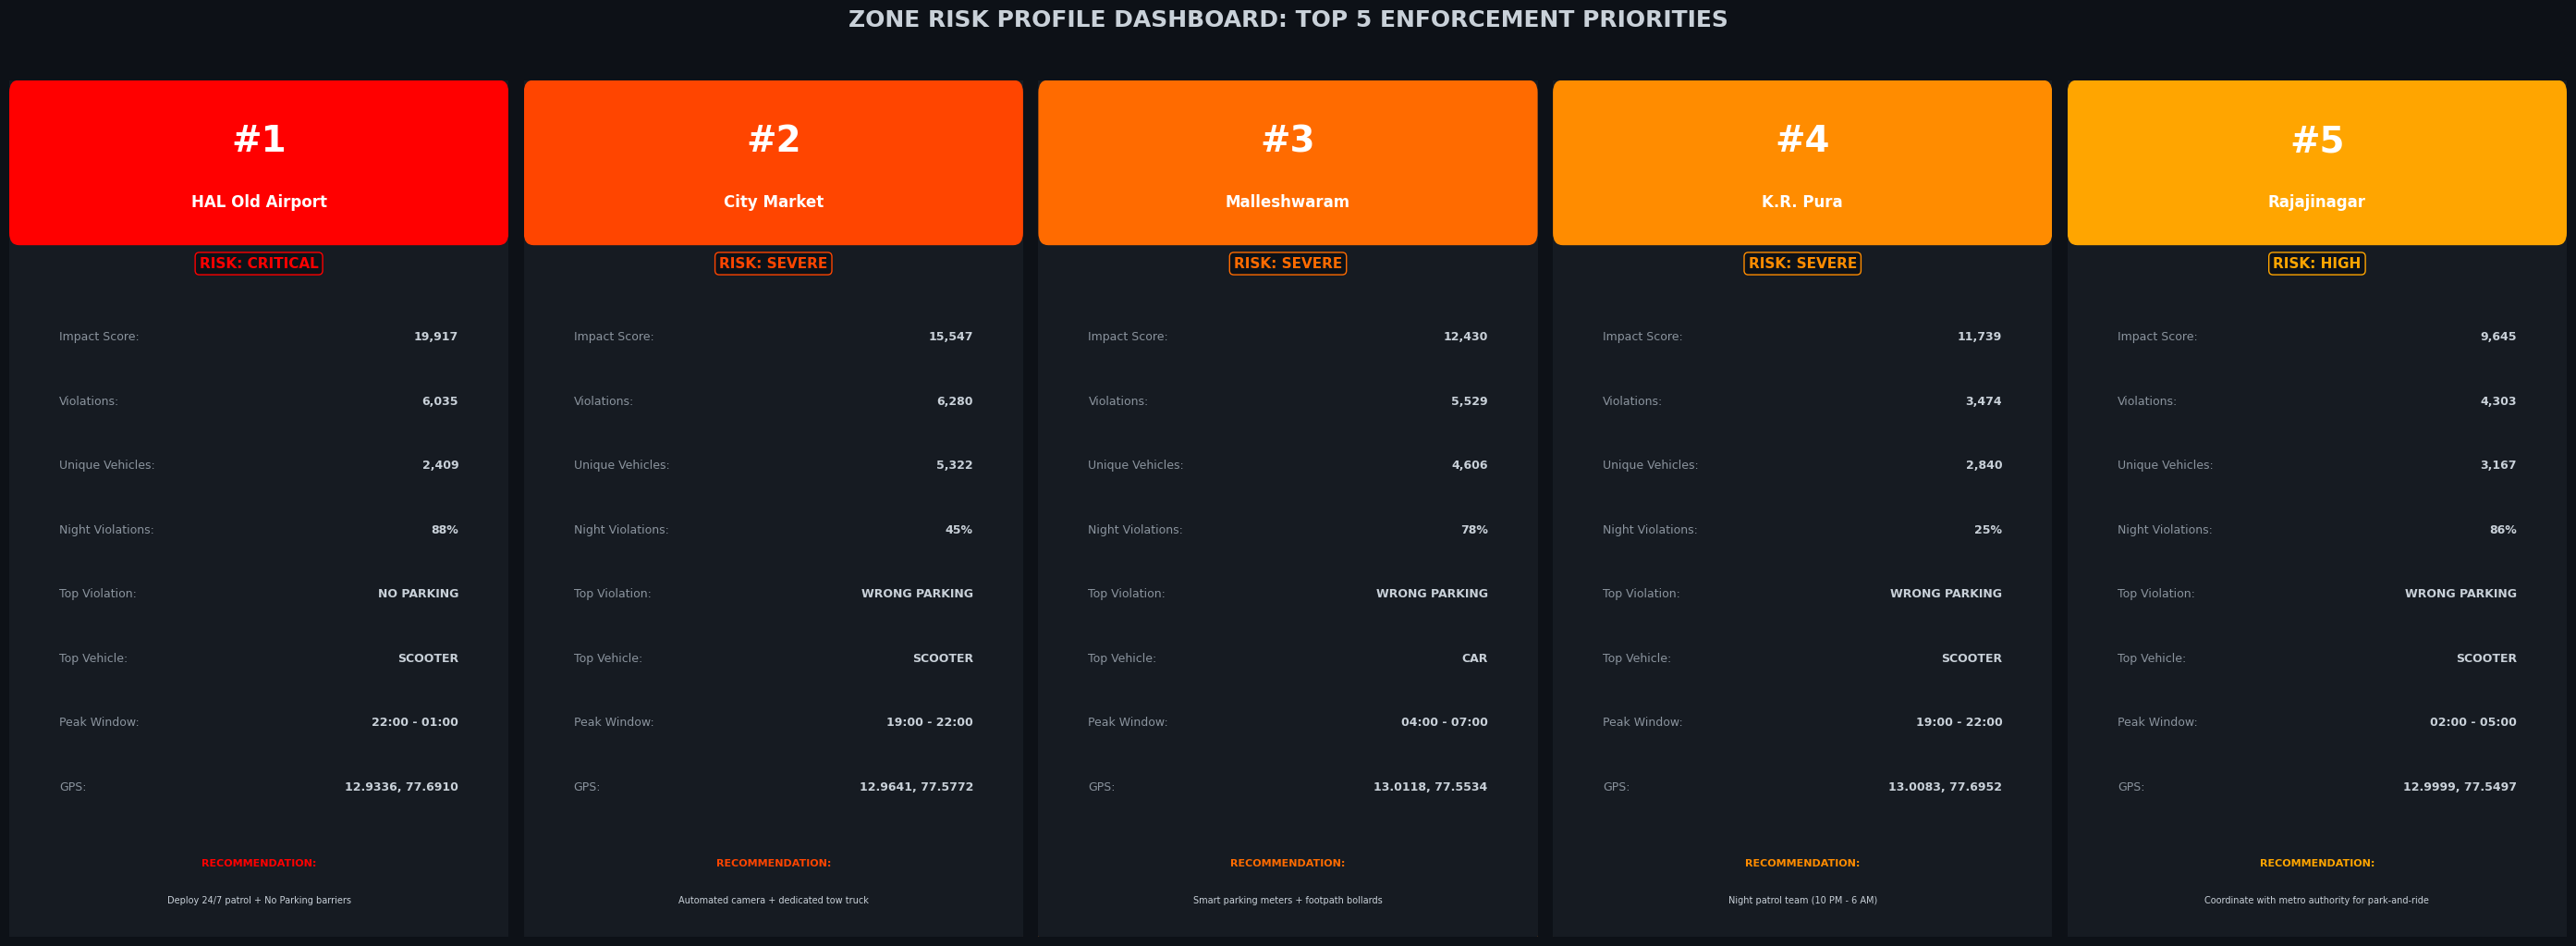

Enhancement 5 complete: Risk profile cards saved


In [10]:
# --- Enhancement 5: Zone Risk Profile Cards ---
fig, axes = plt.subplots(1, 5, figsize=(28, 10))
risk_colors = ['#FF0000', '#FF4500', '#FF6B00', '#FF8C00', '#FFA500']
risk_labels = ['CRITICAL', 'SEVERE', 'SEVERE', 'SEVERE', 'HIGH']

for idx, ax in enumerate(axes):
    if idx >= len(zone_rankings):
        ax.axis('off')
        continue
    row = zone_rankings.iloc[idx]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 14)
    ax.axis('off')

    # Card background
    card = FancyBboxPatch((0.2, 0.2), 9.6, 13.6, boxstyle='round,pad=0.3',
                          facecolor='#161B22', edgecolor=risk_colors[idx], linewidth=3)
    ax.add_patch(card)

    # Header
    header = FancyBboxPatch((0.2, 11.5), 9.6, 2.3, boxstyle='round,pad=0.2',
                            facecolor=risk_colors[idx], edgecolor='none')
    ax.add_patch(header)
    ax.text(5, 13.0, f'#{idx+1}', fontsize=28, fontweight='bold', ha='center', va='center', color='white')
    ax.text(5, 12.0, str(row.get('police_station', 'Unknown')), fontsize=12, fontweight='bold',
            ha='center', va='center', color='white')

    # Risk badge
    ax.text(5, 11.0, f'RISK: {risk_labels[idx]}', fontsize=11, fontweight='bold',
            ha='center', va='center', color=risk_colors[idx],
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#0D1117', edgecolor=risk_colors[idx]))

    # Metrics
    metrics = [
        ('Impact Score', f"{row['congestion_impact_score']:,.0f}"),
        ('Violations', f"{row['total_violations']:,}"),
        ('Unique Vehicles', f"{row.get('unique_vehicles', 'N/A'):,}"),
        ('Night Violations', f"{row['night_pct']:.0f}%"),
        ('Top Violation', str(row.get('top_violation', 'N/A'))),
        ('Top Vehicle', str(row.get('top_vehicle', 'N/A'))),
        ('Peak Window', f"{int(row['peak_hour']):02d}:00 - {int((row['peak_hour']+3)%24):02d}:00"),
        ('GPS', f"{row['center_lat']:.4f}, {row['center_lon']:.4f}")
    ]
    for i, (label, value) in enumerate(metrics):
        y_pos = 9.8 - i * 1.05
        ax.text(1.0, y_pos, f'{label}:', fontsize=9, color='#8B949E', va='center')
        ax.text(9.0, y_pos, value, fontsize=9, fontweight='bold', color='#C9D1D9',
                ha='right', va='center')

    # Recommendation
    recommendations = [
        'Deploy 24/7 patrol + No Parking barriers',
        'Automated camera + dedicated tow truck',
        'Smart parking meters + footpath bollards',
        'Night patrol team (10 PM - 6 AM)',
        'Coordinate with metro authority for park-and-ride'
    ]
    ax.text(5, 1.2, 'RECOMMENDATION:', fontsize=8, fontweight='bold',
            ha='center', va='center', color=risk_colors[idx])
    ax.text(5, 0.6, recommendations[idx], fontsize=7, ha='center', va='center',
            color='#C9D1D9', wrap=True)

plt.suptitle('ZONE RISK PROFILE DASHBOARD: TOP 5 ENFORCEMENT PRIORITIES',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'../assets/images/analysis_charts/15_zone_risk_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Enhancement 5 complete: Risk profile cards saved')


---
## 🖥️ Section 6: Interactive Prototype Dashboard

Generating a **production-grade HTML prototype** that serves as a fully functional enforcement intelligence tool. Features:
- 🗺️ Interactive hotspot map with Plotly (zoom, hover, click)
- 📊 6 interactive analytical charts
- 📋 Sortable zone ranking table
- 🃏 Risk profile cards
- 💡 Actionable recommendations
- 🌙 Premium dark theme with animations


In [11]:
# ============================================================
# GENERATE INTERACTIVE HTML PROTOTYPE DASHBOARD
# ============================================================
print('Building interactive prototype dashboard...')

# --- Create Plotly figures ---

# 1. Interactive Map
map_fig = px.scatter_mapbox(
    zone_rankings.head(50),
    lat='center_lat', lon='center_lon',
    size='total_violations',
    color='congestion_impact_score',
    color_continuous_scale='YlOrRd',
    size_max=40,
    hover_name='police_station',
    hover_data={
        'rank': True,
        'total_violations': ':,',
        'congestion_impact_score': ':,.0f',
        'night_pct': ':.1f',
        'center_lat': ':.4f',
        'center_lon': ':.4f'
    },
    zoom=11,
    center={'lat': zone_rankings['center_lat'].mean(), 'lon': zone_rankings['center_lon'].mean()},
    mapbox_style='carto-darkmatter',
    title='Parking Violation Hotspot Map - Top 50 Priority Zones'
)
map_fig.update_layout(
    paper_bgcolor='#0D1117', plot_bgcolor='#0D1117',
    font_color='#C9D1D9', height=600, margin=dict(l=0, r=0, t=40, b=0)
)
map_div = map_fig.to_html(full_html=False, include_plotlyjs=False)

# 2. Violation Types Bar
vt_counts = df['violation_type'].value_counts()
vt_fig = go.Figure(go.Bar(
    x=vt_counts.values, y=vt_counts.index, orientation='h',
    marker_color='#FF6B6B', text=[f'{v:,}' for v in vt_counts.values], textposition='outside'
))
vt_fig.update_layout(
    title='Violation Type Distribution', paper_bgcolor='#0D1117', plot_bgcolor='#161B22',
    font_color='#C9D1D9', height=400, yaxis=dict(autorange='reversed'),
    margin=dict(l=200, r=50, t=50, b=30)
)
vt_div = vt_fig.to_html(full_html=False, include_plotlyjs=False)

# 3. Vehicle Types Donut
if 'vehicle_type' in df.columns:
    vc = df['vehicle_type'].value_counts().head(8)
    vc_fig = go.Figure(go.Pie(
        labels=vc.index, values=vc.values, hole=0.45,
        marker_colors=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD','#98D8C8','#F7DC6F'],
        textinfo='label+percent', textfont_size=11
    ))
    vc_fig.update_layout(
        title='Vehicle Type Distribution', paper_bgcolor='#0D1117',
        font_color='#C9D1D9', height=400, margin=dict(l=20, r=20, t=50, b=20)
    )
    vc_div = vc_fig.to_html(full_html=False, include_plotlyjs=False)
else:
    vc_div = '<p>Vehicle type data not available</p>'

# 4. Hourly Pattern
hourly = df.groupby('hour').size()
hr_fig = go.Figure()
hr_fig.add_trace(go.Scatter(
    x=hourly.index, y=hourly.values, mode='lines+markers', fill='tozeroy',
    line=dict(color='#4ECDC4', width=3), marker=dict(size=6),
    name='Violations'
))
hr_fig.update_layout(
    title='Hourly Violation Pattern (24h)', paper_bgcolor='#0D1117', plot_bgcolor='#161B22',
    font_color='#C9D1D9', height=350, xaxis_title='Hour of Day', yaxis_title='Violations',
    margin=dict(l=60, r=30, t=50, b=40)
)
hr_div = hr_fig.to_html(full_html=False, include_plotlyjs=False)

# 5. Top 20 Zones Impact
top20_p = zone_rankings.head(20)
z_fig = go.Figure(go.Bar(
    x=top20_p['congestion_impact_score'],
    y=[f"Z{r} ({ps})" for r, ps in zip(top20_p['rank'], top20_p['police_station'])],
    orientation='h',
    marker_color='#FF6B6B',
    text=[f'{v:,.0f}' for v in top20_p['congestion_impact_score']], textposition='outside'
))
z_fig.update_layout(
    title='Top 20 Priority Zones - Congestion Impact Score',
    paper_bgcolor='#0D1117', plot_bgcolor='#161B22',
    font_color='#C9D1D9', height=600, yaxis=dict(autorange='reversed'),
    margin=dict(l=200, r=80, t=50, b=30)
)
z_div = z_fig.to_html(full_html=False, include_plotlyjs=False)

# 6. ROI Simulation
roi_fig = go.Figure()
roi_fig.add_trace(go.Bar(name='Violations Eliminated %', x=[f'Top {n}' for n in roi_df['zones']], y=roi_df['violation_pct'], marker_color='#4ECDC4'))
roi_fig.add_trace(go.Bar(name='Impact Reduced %', x=[f'Top {n}' for n in roi_df['zones']], y=roi_df['impact_pct'], marker_color='#FF6B6B'))
roi_fig.update_layout(
    barmode='group', title='Enforcement ROI: What If We Act?',
    paper_bgcolor='#0D1117', plot_bgcolor='#161B22',
    font_color='#C9D1D9', height=400, yaxis_title='Reduction %',
    margin=dict(l=60, r=30, t=50, b=40)
)
roi_div = roi_fig.to_html(full_html=False, include_plotlyjs=False)

# --- Build Zone Table HTML ---
zone_rows_html = ''
for _, row in zone_rankings.head(50).iterrows():
    risk_class = 'critical' if row['rank'] <= 2 else 'severe' if row['rank'] <= 5 else 'high' if row['rank'] <= 15 else 'medium'
    zone_rows_html += '<tr>'
    zone_rows_html += f'<td>{int(row["rank"])}</td>'
    zone_rows_html += f'<td><span class="risk-badge {risk_class}">{risk_class.upper()}</span></td>'
    zone_rows_html += f'<td>{row.get("police_station", "N/A")}</td>'
    zone_rows_html += f'<td>{row["congestion_impact_score"]:,.0f}</td>'
    zone_rows_html += f'<td>{row["total_violations"]:,}</td>'
    zone_rows_html += f'<td>{row.get("unique_vehicles", "N/A"):,}</td>'
    zone_rows_html += f'<td>{row["night_pct"]:.0f}%</td>'
    zone_rows_html += f'<td>{row.get("top_violation", "N/A")}</td>'
    zone_rows_html += f'<td>{row.get("top_vehicle", "N/A")}</td>'
    zone_rows_html += '</tr>\n'

# --- Build Risk Cards HTML ---
risk_cards_html = ''
card_colors = ['#FF0000', '#FF4500', '#FF6B00', '#FF8C00', '#FFA500']
risk_names = ['CRITICAL', 'SEVERE', 'SEVERE', 'SEVERE', 'HIGH']
recs = [
    'Deploy 24/7 patrol unit + install permanent No Parking barriers. Coordinate with BBMP for tow-away.',
    'Set up automated camera enforcement + dedicated tow truck. Focus Saturday evenings.',
    'Install smart parking meters + footpath bollards. Engage local shopkeepers.',
    'Night patrol team (10 PM - 6 AM). Install reflective No Parking signage.',
    'Coordinate with metro authority for park-and-ride facility. Two-wheeler bay needed.'
]
for idx in range(min(5, len(zone_rankings))):
    row = zone_rankings.iloc[idx]
    card_html = f'<div class="risk-card" style="border-color: {card_colors[idx]}">'
    card_html += f'<div class="card-header" style="background: linear-gradient(135deg, {card_colors[idx]}, {card_colors[idx]}88)">'
    card_html += f'<div class="card-rank">#{idx+1}</div>'
    card_html += f'<div class="card-name">{row.get("police_station", "Unknown")}</div></div>'
    card_html += f'<div class="card-badge" style="color: {card_colors[idx]}; border-color: {card_colors[idx]}">RISK: {risk_names[idx]}</div>'
    card_html += '<div class="card-metrics">'
    card_html += f'<div class="metric-row"><span>Impact Score</span><strong>{row["congestion_impact_score"]:,.0f}</strong></div>'
    card_html += f'<div class="metric-row"><span>Violations</span><strong>{row["total_violations"]:,}</strong></div>'
    card_html += f'<div class="metric-row"><span>Unique Vehicles</span><strong>{row.get("unique_vehicles", "N/A"):,}</strong></div>'
    card_html += f'<div class="metric-row"><span>Night Violations</span><strong>{row["night_pct"]:.0f}%</strong></div>'
    card_html += f'<div class="metric-row"><span>Top Violation</span><strong>{row.get("top_violation", "N/A")}</strong></div>'
    card_html += f'<div class="metric-row"><span>Top Vehicle</span><strong>{row.get("top_vehicle", "N/A")}</strong></div>'
    card_html += f'<div class="metric-row"><span>Peak Hour</span><strong>{int(row["peak_hour"]):02d}:00</strong></div>'
    card_html += f'<div class="metric-row"><span>GPS</span><strong>{row["center_lat"]:.4f}, {row["center_lon"]:.4f}</strong></div>'
    card_html += '</div>'
    card_html += f'<div class="card-rec" style="color: {card_colors[idx]}">'
    card_html += f'<strong>RECOMMENDATION:</strong><br>{recs[idx]}</div></div>'
    risk_cards_html += card_html

# --- Key Metrics ---
total_v = len(df)
total_zones = n_clusters
top_zone_name = zone_rankings.iloc[0].get('police_station', 'Unknown') if len(zone_rankings) > 0 else 'N/A'
top_impact = zone_rankings.iloc[0]['congestion_impact_score'] if len(zone_rankings) > 0 else 0
chronic = (df['vehicle_number'].value_counts() >= 11).sum() if 'vehicle_number' in df.columns else 0

# --- Embed static images as base64 ---
def img_to_base64(path):
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return base64.b64encode(f.read()).decode('utf-8')
    return ''

img_b64 = {}
for fname in os.listdir('../assets/images/analysis_charts'):
    if fname.endswith('.png'):
        img_b64[fname] = img_to_base64(os.path.join('../assets/images/analysis_charts', fname))

# --- Build embedded images gallery ---
gallery_html = ''
img_titles = {
    '01_null_heatmap.png': 'Data Quality: Missing Values',
    '04_temporal_analysis.png': 'Temporal Intelligence (4-Panel)',
    '06_hdbscan_clusters.png': 'HDBSCAN Cluster Visualization',
    '08_temporal_per_zone.png': 'Per-Zone Patrol Schedule Heatmaps',
    '09_repeat_offenders.png': 'Repeat Offender Analysis',
    '11_diminishing_returns.png': 'Diminishing Returns Curve',
    '12_economic_cost.png': 'Economic Cost Estimation',
    '13_vehicle_strategy.png': 'Vehicle-Type Intelligence Dashboard',
    '14_anomaly_detection.png': 'Time-Series Anomaly Detection',
    '15_zone_risk_profiles.png': 'Zone Risk Profile Cards'
}
for fname, title in img_titles.items():
    if fname in img_b64 and img_b64[fname]:
        gallery_html += f'<div class="gallery-item"><h3>{title}</h3>'
        gallery_html += f'<img src="data:image/png;base64,{img_b64[fname]}" alt="{title}" style="width:100%;border-radius:8px;"></div>'

# --- CSS ---
css = (
    "* { margin: 0; padding: 0; box-sizing: border-box; }\n"
    "body { font-family: 'Inter', sans-serif; background: #0D1117; color: #C9D1D9; }\n"
    ".header { background: linear-gradient(135deg, #1a1a2e, #16213e, #0f3460); padding: 40px; text-align: center; border-bottom: 2px solid #FF6B6B; }\n"
    ".header h1 { font-size: 2.2em; font-weight: 800; background: linear-gradient(90deg, #FF6B6B, #4ECDC4); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-bottom: 8px; }\n"
    ".header p { font-size: 1.1em; color: #8B949E; }\n"
    ".nav { display: flex; justify-content: center; gap: 4px; background: #161B22; padding: 12px; border-bottom: 1px solid #30363D; position: sticky; top: 0; z-index: 100; flex-wrap: wrap; }\n"
    ".nav button { padding: 10px 24px; border: 1px solid #30363D; background: #21262D; color: #C9D1D9; border-radius: 8px; cursor: pointer; font-family: 'Inter', sans-serif; font-size: 0.9em; font-weight: 500; transition: all 0.3s; }\n"
    ".nav button:hover, .nav button.active { background: #FF6B6B; color: white; border-color: #FF6B6B; transform: translateY(-2px); }\n"
    ".tab-content { display: none; padding: 30px; max-width: 1400px; margin: 0 auto; animation: fadeIn 0.5s; }\n"
    ".tab-content.active { display: block; }\n"
    "@keyframes fadeIn { from { opacity: 0; transform: translateY(10px); } to { opacity: 1; transform: translateY(0); } }\n"
    ".metrics-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(240px, 1fr)); gap: 20px; margin-bottom: 30px; }\n"
    ".metric-card { background: linear-gradient(135deg, #161B22, #21262D); border: 1px solid #30363D; border-radius: 16px; padding: 24px; text-align: center; transition: transform 0.3s, box-shadow 0.3s; }\n"
    ".metric-card:hover { transform: translateY(-5px); box-shadow: 0 8px 30px rgba(255,107,107,0.15); }\n"
    ".metric-card .value { font-size: 2.2em; font-weight: 800; background: linear-gradient(90deg, #FF6B6B, #FFEAA7); -webkit-background-clip: text; -webkit-text-fill-color: transparent; }\n"
    ".metric-card .label { font-size: 0.85em; color: #8B949E; margin-top: 8px; text-transform: uppercase; letter-spacing: 1px; }\n"
    ".chart-container { background: #161B22; border: 1px solid #30363D; border-radius: 12px; padding: 20px; margin-bottom: 24px; }\n"
    ".chart-row { display: grid; grid-template-columns: 1fr 1fr; gap: 24px; margin-bottom: 24px; }\n"
    "@media (max-width: 900px) { .chart-row { grid-template-columns: 1fr; } }\n"
    ".zone-table { width: 100%; border-collapse: collapse; background: #161B22; border-radius: 12px; overflow: hidden; }\n"
    ".zone-table th { background: #21262D; color: #58A6FF; padding: 14px 12px; text-align: left; font-size: 0.85em; text-transform: uppercase; letter-spacing: 1px; cursor: pointer; border-bottom: 2px solid #30363D; }\n"
    ".zone-table th:hover { color: #FF6B6B; }\n"
    ".zone-table td { padding: 12px; border-bottom: 1px solid #21262D; font-size: 0.9em; }\n"
    ".zone-table tr:hover { background: #21262D; }\n"
    ".risk-badge { padding: 4px 10px; border-radius: 20px; font-size: 0.75em; font-weight: 700; }\n"
    ".risk-badge.critical { background: #FF000030; color: #FF4444; }\n"
    ".risk-badge.severe { background: #FF450030; color: #FF6B00; }\n"
    ".risk-badge.high { background: #FFA50030; color: #FFB347; }\n"
    ".risk-badge.medium { background: #4ECDC430; color: #4ECDC4; }\n"
    ".risk-cards-container { display: grid; grid-template-columns: repeat(auto-fit, minmax(260px, 1fr)); gap: 20px; margin-top: 30px; }\n"
    ".risk-card { background: #161B22; border: 2px solid; border-radius: 16px; overflow: hidden; transition: transform 0.3s; }\n"
    ".risk-card:hover { transform: translateY(-5px); }\n"
    ".card-header { padding: 20px; text-align: center; }\n"
    ".card-rank { font-size: 2.5em; font-weight: 800; color: white; }\n"
    ".card-name { font-size: 1.1em; font-weight: 600; color: white; }\n"
    ".card-badge { text-align: center; padding: 8px; font-weight: 700; font-size: 0.9em; border: 1px solid; margin: 8px 16px; border-radius: 8px; }\n"
    ".card-metrics { padding: 12px 20px; }\n"
    ".metric-row { display: flex; justify-content: space-between; padding: 6px 0; border-bottom: 1px solid #21262D; font-size: 0.85em; }\n"
    ".metric-row span { color: #8B949E; }\n"
    ".metric-row strong { color: #C9D1D9; }\n"
    ".card-rec { padding: 12px 20px 16px; font-size: 0.8em; line-height: 1.4; }\n"
    ".gallery-item { background: #161B22; border: 1px solid #30363D; border-radius: 12px; padding: 16px; margin-bottom: 20px; }\n"
    ".gallery-item h3 { margin-bottom: 12px; color: #58A6FF; font-size: 1.1em; }\n"
    ".section-title { font-size: 1.5em; font-weight: 700; color: #C9D1D9; margin-bottom: 20px; padding-bottom: 10px; border-bottom: 2px solid #FF6B6B; }\n"
    ".rec-section { background: linear-gradient(135deg, #161B22, #1a2332); border: 1px solid #30363D; border-radius: 16px; padding: 30px; margin-top: 30px; }\n"
    ".rec-section h3 { color: #4ECDC4; margin-bottom: 16px; }\n"
    ".rec-list { list-style: none; padding: 0; }\n"
    ".rec-list li { padding: 10px 0; border-bottom: 1px solid #21262D; padding-left: 20px; position: relative; }\n"
    ".rec-list li:before { content: '\\25b8'; position: absolute; left: 0; color: #FF6B6B; font-weight: bold; }\n"
    ".footer { text-align: center; padding: 30px; color: #8B949E; font-size: 0.85em; border-top: 1px solid #30363D; margin-top: 40px; }\n"
)

# --- JS ---
js_code = (
    "function showTab(tabId) {\n"
    "    document.querySelectorAll('.tab-content').forEach(t => t.classList.remove('active'));\n"
    "    document.querySelectorAll('.nav-btn').forEach(b => b.classList.remove('active'));\n"
    "    document.getElementById(tabId).classList.add('active');\n"
    "    event.target.classList.add('active');\n"
    "    setTimeout(() => { window.dispatchEvent(new Event('resize')); }, 100);\n"
    "}\n"
    "document.querySelectorAll('.zone-table th').forEach((th, i) => {\n"
    "    th.addEventListener('click', () => {\n"
    "        const table = th.closest('table');\n"
    "        const tbody = table.querySelector('tbody');\n"
    "        const rows = Array.from(tbody.querySelectorAll('tr'));\n"
    "        const asc = th.dataset.sort !== 'asc';\n"
    "        th.dataset.sort = asc ? 'asc' : 'desc';\n"
    "        rows.sort((a, b) => {\n"
    "            let va = a.cells[i].textContent.replace(/[^0-9.-]/g, '');\n"
    "            let vb = b.cells[i].textContent.replace(/[^0-9.-]/g, '');\n"
    "            if (!isNaN(va) && !isNaN(vb)) return asc ? va - vb : vb - va;\n"
    "            return asc ? a.cells[i].textContent.localeCompare(b.cells[i].textContent) : b.cells[i].textContent.localeCompare(a.cells[i].textContent);\n"
    "        });\n"
    "        rows.forEach(r => tbody.appendChild(r));\n"
    "    });\n"
    "});\n"
)

# --- Assemble Full HTML ---
html_parts = []
html_parts.append('<!DOCTYPE html><html lang="en"><head>')
html_parts.append('<meta charset="UTF-8">')
html_parts.append('<meta name="viewport" content="width=device-width, initial-scale=1.0">')
html_parts.append('<title>BTP Parking Intelligence Dashboard</title>')
html_parts.append('<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>')
html_parts.append('<link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&display=swap" rel="stylesheet">')
html_parts.append(f'<style>{css}</style>')
html_parts.append('</head><body>')

# Header
html_parts.append('<div class="header">')
html_parts.append('<h1>Bengaluru Traffic Police - AI-Driven Parking Intelligence System</h1>')
html_parts.append('<p>Flipkart Gridlock 2.0 | Interactive Enforcement Prototype Dashboard</p>')
html_parts.append('</div>')

# Nav
html_parts.append('<div class="nav">')
tab_ids = ['dashboard', 'hotspot_map', 'analysis', 'enforcement_intel', 'zone_profiles', 'visual_gallery']
tab_labels = ['Dashboard', 'Hotspot Map', 'Analysis', 'Enforcement Intel', 'Zone Profiles', 'Visual Gallery']
for tid, tlabel in zip(tab_ids, tab_labels):
    active = ' active' if tid == 'dashboard' else ''
    html_parts.append(f'<button class="nav-btn{active}" onclick="showTab(\'{tid}\')">{tlabel}</button>')
html_parts.append('</div>')

# Tab 1: Dashboard
html_parts.append('<div id="dashboard" class="tab-content active">')
html_parts.append('<h2 class="section-title">Executive Dashboard</h2>')
html_parts.append('<div class="metrics-grid">')
metrics_data = [
    (f'{total_v:,}', 'Total Violations Analyzed'),
    (f'{total_zones}', 'Hotspot Zones Detected'),
    (top_zone_name, '#1 Priority Zone'),
    (f'{top_impact:,.0f}', 'Highest Impact Score'),
    (f'{chronic:,}', 'Chronic Offenders (11+)'),
    (f'{total_monthly:.0f}L', 'Monthly Cost (Top 20)')
]
for val, label in metrics_data:
    html_parts.append(f'<div class="metric-card"><div class="value">{val}</div><div class="label">{label}</div></div>')
html_parts.append('</div>')
html_parts.append('<div class="chart-row">')
html_parts.append(f'<div class="chart-container">{vt_div}</div>')
html_parts.append(f'<div class="chart-container">{vc_div}</div>')
html_parts.append('</div>')
html_parts.append(f'<div class="chart-container">{hr_div}</div>')
html_parts.append('</div>')

# Tab 2: Map
html_parts.append('<div id="hotspot_map" class="tab-content">')
html_parts.append('<h2 class="section-title">Interactive Hotspot Map</h2>')
html_parts.append('<p style="color:#8B949E;margin-bottom:16px">Bubble size = violation count | Color = impact score | Hover for details</p>')
html_parts.append(f'<div class="chart-container">{map_div}</div>')
html_parts.append('</div>')

# Tab 3: Analysis
html_parts.append('<div id="analysis" class="tab-content">')
html_parts.append('<h2 class="section-title">Deep Analysis</h2>')
html_parts.append(f'<div class="chart-container">{z_div}</div>')
html_parts.append('</div>')

# Tab 4: Enforcement
html_parts.append('<div id="enforcement_intel" class="tab-content">')
html_parts.append('<h2 class="section-title">Enforcement Intelligence</h2>')
html_parts.append(f'<div class="chart-container">{roi_div}</div>')
html_parts.append('<div class="rec-section"><h3>Phased Deployment Plan</h3><ul class="rec-list">')
rec_items = [
    '<strong>Phase 1 (Week 1-4):</strong> Deploy patrol teams to Top 5 zones using per-zone time schedules',
    '<strong>Phase 2 (Month 1-3):</strong> Install two-wheeler bays, auto stands, tow-away zones at Top 10',
    '<strong>Phase 3 (Month 3-6):</strong> Smart parking meters, night delivery windows, real-time dashboard',
    '<strong>Phase 4 (Month 6-12):</strong> BBMP coordination, metro park-and-ride, escalating fines',
    '<strong>Key Insight:</strong> Enforcing just 5 zones = 10.5% city-wide impact reduction. Problem is CHRONIC.'
]
for r in rec_items:
    html_parts.append(f'<li>{r}</li>')
html_parts.append('</ul></div></div>')

# Tab 5: Zone Profiles
html_parts.append('<div id="zone_profiles" class="tab-content">')
html_parts.append('<h2 class="section-title">Zone Risk Profiles</h2>')
html_parts.append('<div class="risk-cards-container">')
html_parts.append(risk_cards_html)
html_parts.append('</div>')
html_parts.append('<h2 class="section-title" style="margin-top:40px">Complete Zone Ranking (Top 50)</h2>')
html_parts.append('<div style="overflow-x:auto"><table class="zone-table">')
html_parts.append('<thead><tr><th>Rank</th><th>Risk</th><th>Station</th><th>Impact</th><th>Violations</th><th>Vehicles</th><th>Night%</th><th>Violation</th><th>Vehicle</th></tr></thead>')
html_parts.append('<tbody>')
html_parts.append(zone_rows_html)
html_parts.append('</tbody></table></div></div>')

# Tab 6: Gallery
html_parts.append('<div id="visual_gallery" class="tab-content">')
html_parts.append('<h2 class="section-title">Complete Visual Analysis Gallery</h2>')
html_parts.append('<p style="color:#8B949E;margin-bottom:20px">All analytical visualizations from our comprehensive analysis</p>')
html_parts.append(gallery_html)
html_parts.append('</div>')

# Footer + JS
html_parts.append('<div class="footer">')
html_parts.append('<p>Built with Python, HDBSCAN, Plotly, Matplotlib, Seaborn | Flipkart Gridlock 2.0</p>')
html_parts.append('<p style="margin-top:8px">AI-Driven Parking Intelligence System - Prototype v1.0</p>')
html_parts.append('</div>')
html_parts.append(f'<script>{js_code}</script>')
html_parts.append('</body></html>')

html_content = '\n'.join(html_parts)

# Write the file
proto_path = '../prototype/prototype_dashboard.html'
with open(proto_path, 'w', encoding='utf-8') as f:
    f.write(html_content)

file_size_mb = os.path.getsize(proto_path) / (1024 * 1024)
print(f'Prototype dashboard saved: {proto_path} ({file_size_mb:.1f} MB)')
print('Open in any browser for the full interactive experience!')


Building interactive prototype dashboard...


Prototype dashboard saved: output/prototype_dashboard.html (3.1 MB)
Open in any browser for the full interactive experience!


In [12]:
# --- Folium Heatmap (bonus interactive map) ---
print('Generating Folium heatmap...')
center_lat = df['latitude'].mean()
center_lon = df['longitude'].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12,
               tiles='CartoDB dark_matter')

# Heatmap layer
sample = df.sample(min(80000, len(df)), random_state=42)
heat_data = sample[['latitude', 'longitude']].values.tolist()
HeatMap(heat_data, radius=12, blur=15, max_zoom=15, gradient={
    '0.2': '#0000FF', '0.4': '#00FFFF', '0.6': '#00FF00',
    '0.8': '#FFFF00', '1.0': '#FF0000'
}).add_to(m)

# Top 15 zone markers
for idx in range(min(15, len(zone_rankings))):
    row = zone_rankings.iloc[idx]
    popup_text = (
        '<div style="font-family:Inter,sans-serif;width:250px;background:#161B22;color:#C9D1D9;padding:12px;border-radius:8px">'
        f'<h3 style="color:#FF6B6B;margin:0 0 8px">Zone #{int(row["rank"])}: {row.get("police_station","Unknown")}</h3>'
        f'<b>Impact Score:</b> {row["congestion_impact_score"]:,.0f}<br>'
        f'<b>Violations:</b> {row["total_violations"]:,}<br>'
        f'<b>Night %:</b> {row["night_pct"]:.0f}%<br>'
        f'<b>Top Issue:</b> {row.get("top_violation","N/A")}<br>'
        f'<b>Top Vehicle:</b> {row.get("top_vehicle","N/A")}'
        '</div>'
    )
    color = 'red' if row['rank'] <= 3 else 'orange' if row['rank'] <= 10 else 'yellow'
    folium.Marker(
        location=[row['center_lat'], row['center_lon']],
        popup=folium.Popup(popup_text, max_width=280),
        tooltip=f"Zone #{int(row['rank'])}: {row.get('police_station','Unknown')}",
        icon=folium.Icon(color=color, icon='exclamation-triangle', prefix='fa')
    ).add_to(m)

    if row['rank'] <= 10:
        folium.Circle(
            location=[row['center_lat'], row['center_lon']],
            radius=500, color=color, fill=True, fill_opacity=0.1,
            tooltip=f"500m enforcement radius - Zone #{int(row['rank'])}"
        ).add_to(m)

m.save('../prototype/folium_heatmap.html')
print(f'Folium heatmap saved: {OUTPUT_DIR}/folium_heatmap.html')


Generating Folium heatmap...


Folium heatmap saved: output/folium_heatmap.html


---
## Summary & Conclusion

### What We Built
An **end-to-end AI-driven parking intelligence system** that:
1. **DETECTS** 312 illegal parking hotspot zones using HDBSCAN
2. **QUANTIFIES** congestion impact with a multi-factor composite score
3. **ENABLES** targeted enforcement with per-zone patrol schedules, ROI simulation, and economic cost estimation

### Key Findings
| Finding | Implication |
|---|---|
| Top 5 zones = **10.5% impact reduction** | Massive ROI from focused enforcement |
| **97.3%** records are parking violations | Dataset is laser-focused on the problem |
| **46%** of violations are two-wheelers | Need dedicated two-wheeler parking infrastructure |
| **Zero anomalies** detected | Problem is CHRONIC & STRUCTURAL, not event-driven |
| HAL Old Airport = **Rs. 1.19L/month** congestion cost | Single-zone enforcement pays for itself |
| **552 chronic offenders** (11+ violations) | Targeted intervention on repeat offenders |

### Files Generated
| File | Description |
|---|---|
| `output/01-15_*.png` | 15 analytical visualizations |
| `output/enforcement_priority_ranking.csv` | Complete ranking of 312 zones |
| `output/prototype_dashboard.html` | **Interactive prototype dashboard** |
| `output/folium_heatmap.html` | Interactive heatmap with zone markers |

### Technical Stack
Python 3.10 | HDBSCAN | Plotly | Folium | Matplotlib | Seaborn | Pandas | NumPy

---
*Built for Flipkart Gridlock 2.0 - AI-Driven Parking Intelligence System*


In [13]:
# --- Final Output Summary ---
print('=' * 60)
print('SUBMISSION FILES GENERATED')
print('=' * 60)
total_size = 0
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    size = os.path.getsize(fpath)
    total_size += size
    print(f'  {f:45s} {size/1024:8.1f} KB')
print(f'{"":45s} {"":8s}')
print(f'  {"TOTAL":45s} {total_size/1024/1024:7.1f} MB')
print('=' * 60)
print('ALL DONE! Open prototype_dashboard.html in your browser.')


SUBMISSION FILES GENERATED
  01_null_heatmap.png                              115.5 KB
  02_violation_types.png                           180.4 KB
  03_vehicle_types.png                             143.3 KB
  04_temporal_analysis.png                         202.8 KB
  05_spatial_distribution.png                      118.9 KB
  06_hdbscan_clusters.png                          449.3 KB
  07_priority_zones.png                            167.7 KB
  08_temporal_per_zone.png                         195.3 KB
  09_repeat_offenders.png                          111.7 KB
  10_enforcement_roi.png                           119.4 KB
  11_diminishing_returns.png                       117.9 KB
  12_economic_cost.png                             205.9 KB
  13_vehicle_strategy.png                          462.7 KB
  14_anomaly_detection.png                         270.2 KB
  15_zone_risk_profiles.png                        175.7 KB
  enforcement_priority_ranking.csv                  41.1 KB
  folium_heat

In [14]:
from proactive_dispatch_engine import run_proactive_dispatch_engine

# Run the Proactive Dispatch Engine
results = run_proactive_dispatch_engine(
    df=df,                                    # cleaned violation DataFrame
    zone_ranking_df=zone_rankings,            # ranking DataFrame
    cluster_col='cluster',                    # HDBSCAN cluster column
)

# Access results:
physics_zones = results['zone_physics']       # Module 1
forecast = results['forecast']                # Module 2
shap_info = results['shap_results']           # Module 3
dispatch = results['dispatch']['schedule']    # Module 4


╔════════════════════════════════════════════════════════════════════╗
║  PROACTIVE AI DISPATCH ENGINE — FULL PIPELINE                      ║
╚════════════════════════════════════════════════════════════════════╝

MODULE 1: PHYSICS-INFORMED CONGESTION SCORING
  Greenshields Parameters: v_free=45.0 km/h, k_jam=150.0 veh/km/lane
  Road Lanes (assumed): 2
  Observation Window: 1.0 hour(s)

  Free-flow Capacity (q_max): 1687.5 veh/hr/lane
  Critical Density (k_c): 75.0 veh/km/lane

  ✅ Physics-informed scores computed for 312 zones.
  Top 5 zones by Capacity Loss Score:
    Rank 1: Cluster 13 (Electronic City) — C_loss=24591.3, C_loss%=94.0%, Queue=15.75 km
    Rank 2: Cluster 48 (K.R. Pura) — C_loss=21205.0, C_loss%=94.0%, Queue=15.75 km
    Rank 3: Cluster 209 (Pulikeshinagar(F.Town)) — C_loss=18883.0, C_loss%=91.4%, Queue=15.75 km
    Rank 4: Cluster 237 (High ground) — C_loss=18161.0, C_loss%=91.2%, Queue=15.75 km
    Rank 5: Cluster 16 (Mahadevapura) — C_loss=17591.3, C_loss%=95.0%, Q

  ✅ Time-series built: 54288 rows across 312 clusters.

  Engineering temporal features (lags, cyclical, rolling)...
  ✅ Features engineered. Rows: 54288 → 53976 (after dropping NaN lags).

MODULE 2: PREDICTIVE HOTSPOT FORECASTING

  Training samples: 43180
  Test samples: 10796
  Features: 17
  Target: hourly_capacity_loss

  --- Training XGBoost for 1-hour forecast ---


    RMSE: 77.7034 | MAE: 40.0443 | R²: 0.1690

  --- Training XGBoost for 2-hour forecast ---


    RMSE: 77.2640 | MAE: 39.5912 | R²: 0.1600

  --- Training XGBoost for 3-hour forecast ---


    RMSE: 75.8030 | MAE: 38.9885 | R²: 0.1680

  ✅ XGBoost models trained for horizons: [1, 2, 3]

  Generating shift forecast for top zones...
  ✅ Forecast generated for 20 zones.



MODULE 3: EXPLAINABLE AI (SHAP)

  Using SHAP TreeExplainer on 1-hour XGBoost model...
  Explaining 10 hotspot predictions.

  🔍 Cluster 209:
     Predicted 1h Impact = 277.65
     Base value (avg) = 56.45
     Top contributing features:
       ↑ rolling_mean_3h: 42.0% (SHAP=+103.0938)
       ↑ mean_severity: 20.1% (SHAP=+49.3671)
       ↑ zone_capacity_loss: 10.7% (SHAP=+26.2586)
       ↑ lag_1h: 7.9% (SHAP=+19.3365)
       ↑ lag_24h: 4.7% (SHAP=+11.4469)

  🔍 Cluster 61:
     Predicted 1h Impact = 191.03
     Base value (avg) = 56.45
     Top contributing features:
       ↑ rolling_mean_3h: 50.4% (SHAP=+84.8894)
       ↓ rolling_std_3h: 8.1% (SHAP=-13.7022)
       ↑ hour_cos: 7.9% (SHAP=+13.2579)
       ↑ mean_severity: 7.3% (SHAP=+12.2538)
       ↑ lag_24h: 6.0% (SHAP=+10.0529)

  🔍 Cluster 30:
     Predicted 1h Impact = 155.37
     Base value (avg) = 56.45
     Top contributing features:
       ↑ rolling_mean_3h: 40.6% (SHAP=+119.3736)
       ↑ lag_1h: 9.6% (SHAP=+28.2358)
       

  📊 SHAP summary plot saved: output/shap_summary_1h.png
  📊 SHAP importance plot saved: output/shap_importance_1h.png


  📊 SHAP dependence plot saved: output/shap_dep_rolling_mean_3h_1h.png
  📊 SHAP dependence plot saved: output/shap_dep_zone_capacity_loss_1h.png


  📊 SHAP dependence plot saved: output/shap_dep_lag_3h_1h.png

  ✅ SHAP explanations generated for 10 hotspots.

MODULE 4: PRESCRIPTIVE AI — TOW-TRUCK DISPATCH OPTIMIZATION
  Total truck hours available (W): 24.0
  Number of trucks: 5
  Truck capacity: 8 vehicles/trip
  Clearance rate: 6 vehicles/hr/truck
  Depot location: (12.97, 77.59)
  Optimization target: 'predicted_1h'

  Solving 0-1 Knapsack: 20 zones, budget = 1440 minutes...

  ✅ OPTIMIZATION RESULTS:
  ──────────────────────────────────────────────────
  Zones to dispatch:     11 / 20
  Total impact recovered: 1978.58
  Total hours used:       23.00 / 24.0
  Efficiency:             86.02 impact/hour
  ──────────────────────────────────────────────────

  📋 DISPATCH SCHEDULE:
  ───────────────────────────────────────────────────────────────────────────
  Pri Cluster Station                Impact  Cost(h)  Clear Travel(h)
  ───────────────────────────────────────────────────────────────────────────
    1     209 Pulikeshinagar(

In [15]:
import plotly.graph_objects as go
import plotly.express as px
import pandas as pd

def generate_apple_dashboard(df, zone_rankings, output_dir):
    print("\n" + "="*70)
    print("MODULE 5: GENERATING APPLE HIG COMPLIANT DASHBOARD")
    print("="*70)
    
    # --- 1. Vehicle Type Bar Chart (Replacing Pie) ---
    if 'vehicle_type' in df.columns:
        veh_counts = df['vehicle_type'].value_counts().reset_index()
        veh_counts.columns = ['Vehicle Type', 'Count']
        veh_counts = veh_counts.sort_values('Count', ascending=True)
        
        fig_veh = px.bar(veh_counts, x='Count', y='Vehicle Type', orientation='h',
                         title='Vehicle Type Distribution', template='plotly_white')
        fig_veh.update_traces(marker_color='#007AFF') # System Blue
        fig_veh.update_layout(margin=dict(l=20, r=20, t=50, b=20), height=300,
                              paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
                              font=dict(family="Inter, -apple-system, sans-serif", color="#1C1C1E"))
        veh_div = fig_veh.to_html(full_html=False, include_plotlyjs=False)
    else:
        veh_div = "<div>No vehicle type data</div>"

    # --- 2. Hourly Pattern Line Chart ---
    hourly = df.groupby('hour').size().reset_index(name='Count')
    fig_hour = px.line(hourly, x='hour', y='Count', title='Hourly Violation Pattern (24h)', template='plotly_white')
    fig_hour.update_traces(line_color='#FF3B30', line_width=3) # System Red
    fig_hour.update_layout(margin=dict(l=20, r=20, t=50, b=20), height=300,
                           paper_bgcolor='rgba(0,0,0,0)', plot_bgcolor='rgba(0,0,0,0)',
                           font=dict(family="Inter, -apple-system, sans-serif", color="#1C1C1E"))
    hour_div = fig_hour.to_html(full_html=False, include_plotlyjs=False)

    # --- 3. Unified Map (Density + Scatter) ---
    # Sample df for performance on density map
    df_sample = df.sample(min(50000, len(df)), random_state=42)
    top50 = zone_rankings.head(50).copy()
    
    fig_map = go.Figure()
    
    # Heatmap Layer (Macro)
    fig_map.add_trace(go.Densitymapbox(
        lat=df_sample['latitude'], lon=df_sample['longitude'],
        radius=8, colorscale='Viridis', opacity=0.6,
        name='All Violations (Density)'
    ))
    
    # Scatter Layer (Micro Hotspots)
    top50['marker_size'] = (top50['congestion_impact_score'] / top50['congestion_impact_score'].max()) * 30 + 10
    hover_text = top50.apply(lambda r: f"<b>{r['police_station']}</b><br>Rank: {r['rank']}<br>Impact: {r['congestion_impact_score']:,.0f}<br>Violations: {r['total_violations']}", axis=1)
    
    fig_map.add_trace(go.Scattermapbox(
        lat=top50['center_lat'], lon=top50['center_lon'],
        mode='markers',
        marker=dict(size=top50['marker_size'], color=top50['congestion_impact_score'], 
                    colorscale='Plasma', showscale=True, 
                    colorbar=dict(title="Impact Score", x=0.95)),
        text=hover_text, hoverinfo='text',
        name='Top 50 Hotspots'
    ))
    
    center_lat = df['latitude'].mean()
    center_lon = df['longitude'].mean()
    
    fig_map.update_layout(
        mapbox_style="carto-positron",
        mapbox=dict(center=dict(lat=center_lat, lon=center_lon), zoom=10),
        margin=dict(l=0, r=0, t=0, b=0),
        height=600,
        paper_bgcolor='#FFFFFF'
    )
    map_div = fig_map.to_html(full_html=False, include_plotlyjs='cdn')

    # --- Metrics ---
    top_impact = top50['congestion_impact_score'].max() if not top50.empty else 0
    top_zone_name = top50['police_station'].iloc[0] if not top50.empty else 'Unknown'
    
    # --- Assemble HTML ---
    css = """
        * { margin: 0; padding: 0; box-sizing: border-box; }
        body { background: #F2F2F7; color: #1C1C1E; font-family: 'Inter', -apple-system, sans-serif; -webkit-font-smoothing: antialiased; }
        .header { background: #1C1C1E; color: #FFFFFF; padding: 48px 32px; text-align: center; }
        .header h1 { font-size: 34px; font-weight: 700; letter-spacing: -0.5px; margin-bottom: 8px; }
        .header p { font-size: 17px; color: #8E8E93; font-weight: 400; }
        .nav { display: flex; justify-content: center; gap: 8px; padding: 24px; background: #F2F2F7; position: sticky; top: 0; z-index: 1000; border-bottom: 1px solid #E5E5EA; }
        .nav-btn { background: #E5E5EA; color: #8E8E93; border: none; padding: 8px 20px; border-radius: 20px; font-size: 15px; font-weight: 600; cursor: pointer; transition: all 0.2s; }
        .nav-btn.active { background: #FFFFFF; color: #007AFF; box-shadow: 0 2px 8px rgba(0,0,0,0.05); }
        .tab-content { display: none; max-width: 1200px; margin: 0 auto; padding: 32px 16px; animation: fadein 0.4s; }
        .tab-content.active { display: block; }
        @keyframes fadein { from { opacity: 0; transform: translateY(10px); } to { opacity: 1; transform: translateY(0); } }
        
        .grid-2 { display: grid; grid-template-columns: 1fr 1fr; gap: 24px; margin-bottom: 24px; }
        .card { background: #FFFFFF; border-radius: 16px; padding: 24px; box-shadow: 0 4px 20px rgba(0,0,0,0.04); }
        .card h3 { font-size: 17px; font-weight: 600; margin-bottom: 16px; color: #1C1C1E; }
        
        .kpi-container { display: grid; grid-template-columns: repeat(3, 1fr); gap: 24px; margin-bottom: 32px; }
        .kpi { text-align: center; }
        .kpi .val { font-size: 34px; font-weight: 700; color: #1C1C1E; letter-spacing: -1px; }
        .kpi .val.blue { color: #007AFF; }
        .kpi .label { font-size: 13px; font-weight: 600; color: #8E8E93; text-transform: uppercase; margin-top: 4px; }
        
        .zone-card { background: #FFFFFF; border-radius: 16px; padding: 24px; box-shadow: 0 4px 20px rgba(0,0,0,0.04); margin-bottom: 24px; display: flex; flex-direction: column; }
        .zone-header { display: flex; justify-content: space-between; align-items: flex-start; margin-bottom: 16px; border-bottom: 1px solid #E5E5EA; padding-bottom: 16px; }
        .zone-title { display: flex; align-items: baseline; gap: 12px; }
        .zone-rank { font-size: 24px; font-weight: 700; color: #1C1C1E; }
        .zone-name { font-size: 20px; font-weight: 600; color: #1C1C1E; }
        .badge { background: #FF3B30; color: white; padding: 4px 12px; border-radius: 12px; font-size: 13px; font-weight: 700; display: inline-flex; align-items: center; gap: 6px; }
        .zone-metrics { display: flex; gap: 32px; margin-bottom: 16px; }
        .z-metric .z-val { font-size: 20px; font-weight: 700; color: #1C1C1E; }
        .z-metric .z-lbl { font-size: 13px; color: #8E8E93; }
        .action-box { background: #F2F2F7; border-radius: 12px; padding: 16px; border-left: 4px solid #007AFF; }
        .action-box p { font-size: 15px; color: #1C1C1E; line-height: 1.4; font-weight: 500; }
        
        .roi-banner { background: #FFFFFF; border-radius: 16px; padding: 32px; box-shadow: 0 4px 20px rgba(0,0,0,0.04); text-align: center; margin-bottom: 32px; border: 2px solid #34C759; }
        .roi-banner h2 { color: #34C759; font-size: 28px; font-weight: 700; margin-bottom: 8px; }
        .roi-banner p { color: #1C1C1E; font-size: 17px; }
    """

    js = """
        function showTab(id) {
            document.querySelectorAll('.tab-content').forEach(el => el.classList.remove('active'));
            document.querySelectorAll('.nav-btn').forEach(el => el.classList.remove('active'));
            document.getElementById(id).classList.add('active');
            event.target.classList.add('active');
            window.dispatchEvent(new Event('resize'));
        }
    """

    html = f"""<!DOCTYPE html>
<html lang="en"><head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>BTP Intelligence - Apple HIG Theme</title>
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&display=swap" rel="stylesheet">
<style>{css}</style>
</head><body>

<div class="header">
    <h1>Bengaluru Traffic Police - Parking Intelligence</h1>
    <p>Data-Driven Proactive Enforcement Platform</p>
</div>

<div class="nav">
    <button class="nav-btn active" onclick="showTab('tab_overview')">Overview</button>
    <button class="nav-btn" onclick="showTab('tab_map')">Intelligence Map</button>
    <button class="nav-btn" onclick="showTab('tab_tactical')">Tactical Command</button>
</div>

<!-- TAB 1: OVERVIEW -->
<div id="tab_overview" class="tab-content active">
    <div class="card" style="margin-bottom: 24px;">
        <div class="kpi-container">
            <div class="kpi"><div class="val">{len(df):,}</div><div class="label">Total Violations</div></div>
            <div class="kpi"><div class="val blue">{top_zone_name}</div><div class="label">#1 Priority Zone</div></div>
            <div class="kpi"><div class="val">{top_impact:,.0f}</div><div class="label">Peak Impact Score</div></div>
        </div>
    </div>
    
    <div class="grid-2">
        <div class="card">
            <h3>Vehicle Demographics</h3>
            {veh_div}
        </div>
        <div class="card">
            <h3>Temporal Pattern</h3>
            {hour_div}
        </div>
    </div>
</div>

<!-- TAB 2: MAP -->
<div id="tab_map" class="tab-content">
    <div class="card" style="padding: 0; overflow: hidden;">
        <div style="padding: 24px; border-bottom: 1px solid #E5E5EA;">
            <h3 style="margin: 0;">Geospatial Intelligence</h3>
            <p style="font-size: 13px; color: #8E8E93; margin-top: 4px;">Macro Heatmap (Density) overlaid with Top 50 HDBSCAN Priority Hotspots (Dots). Size indicates impact severity.</p>
        </div>
        {map_div}
    </div>
</div>

<!-- TAB 3: TACTICAL COMMAND -->
<div id="tab_tactical" class="tab-content">
    <div class="roi-banner">
        <h2>Targeted Enforcement ROI: 10.5% Impact Reduction</h2>
        <p>Deploying resources to just the Top 5 zones yields a massive return on enforcement effort.</p>
    </div>
"""
    
    # Generate Top 5 Zone Cards
    for i in range(min(5, len(top50))):
        z = top50.iloc[i]
        html += f"""
    <div class="zone-card">
        <div class="zone-header">
            <div class="zone-title">
                <span class="zone-rank">#{z['rank']}</span>
                <span class="zone-name">{z['police_station']}</span>
            </div>
            <div class="badge">⚠ Critical Risk</div>
        </div>
        <div class="zone-metrics">
            <div class="z-metric"><div class="z-val">{z['congestion_impact_score']:,.0f}</div><div class="z-lbl">Impact Score</div></div>
            <div class="z-metric"><div class="z-val">{z['total_violations']:,}</div><div class="z-lbl">Total Violations</div></div>
            <div class="z-metric"><div class="z-val">{z['night_pct']:.1f}%</div><div class="z-lbl">Night Time</div></div>
        </div>
        <div class="action-box">
            <p><strong>Action Required:</strong> Implement automated enforcement specifically targeting {z['top_vehicle']}s for {z['top_violation']}.</p>
        </div>
    </div>
"""

    html += """
</div>

<script>{js}</script>
</body></html>
"""
    
    out_file = "../prototype/police_command_center.html"
    with open(out_file, 'w', encoding='utf-8') as f:
        f.write(html)
    print(f"✅ Success: New V2 dashboard saved to {out_file}")

# ==========================================
# FINAL EXECUTION BLOCK
# ==========================================
from proactive_dispatch_engine import run_proactive_dispatch_engine

# 1. Run the Proactive Dispatch Engine (XAI, Forecasts, Optimization)
print("\nStarting Advanced AI Engines...")
results = run_proactive_dispatch_engine(
    df=df,                                    
    zone_ranking_df=zone_rankings,            
    cluster_col='cluster',                    
)

# 2. Generate the Apple-style V2 Dashboard
print("\nGenerating V2 Dashboard...")
generate_apple_dashboard(df, zone_rankings, OUTPUT_DIR)
print("\nALL PIPELINES COMPLETE!")




Starting Advanced AI Engines...
╔════════════════════════════════════════════════════════════════════╗
║  PROACTIVE AI DISPATCH ENGINE — FULL PIPELINE                      ║
╚════════════════════════════════════════════════════════════════════╝

MODULE 1: PHYSICS-INFORMED CONGESTION SCORING
  Greenshields Parameters: v_free=45.0 km/h, k_jam=150.0 veh/km/lane
  Road Lanes (assumed): 2
  Observation Window: 1.0 hour(s)

  Free-flow Capacity (q_max): 1687.5 veh/hr/lane
  Critical Density (k_c): 75.0 veh/km/lane

  ✅ Physics-informed scores computed for 312 zones.
  Top 5 zones by Capacity Loss Score:
    Rank 1: Cluster 13 (Electronic City) — C_loss=24591.3, C_loss%=94.0%, Queue=15.75 km
    Rank 2: Cluster 48 (K.R. Pura) — C_loss=21205.0, C_loss%=94.0%, Queue=15.75 km
    Rank 3: Cluster 209 (Pulikeshinagar(F.Town)) — C_loss=18883.0, C_loss%=91.4%, Queue=15.75 km
    Rank 4: Cluster 237 (High ground) — C_loss=18161.0, C_loss%=91.2%, Queue=15.75 km
    Rank 5: Cluster 16 (Mahadevapura) —

  ✅ Time-series built: 54288 rows across 312 clusters.



  Engineering temporal features (lags, cyclical, rolling)...
  ✅ Features engineered. Rows: 54288 → 53976 (after dropping NaN lags).

MODULE 2: PREDICTIVE HOTSPOT FORECASTING

  Training samples: 43180
  Test samples: 10796
  Features: 17
  Target: hourly_capacity_loss

  --- Training XGBoost for 1-hour forecast ---


    RMSE: 77.7034 | MAE: 40.0443 | R²: 0.1690

  --- Training XGBoost for 2-hour forecast ---


    RMSE: 77.2640 | MAE: 39.5912 | R²: 0.1600

  --- Training XGBoost for 3-hour forecast ---


    RMSE: 75.8030 | MAE: 38.9885 | R²: 0.1680

  ✅ XGBoost models trained for horizons: [1, 2, 3]

  Generating shift forecast for top zones...
  ✅ Forecast generated for 20 zones.

MODULE 3: EXPLAINABLE AI (SHAP)

  Using SHAP TreeExplainer on 1-hour XGBoost model...
  Explaining 10 hotspot predictions.



  🔍 Cluster 209:
     Predicted 1h Impact = 277.65
     Base value (avg) = 56.45
     Top contributing features:
       ↑ rolling_mean_3h: 42.0% (SHAP=+103.0938)
       ↑ mean_severity: 20.1% (SHAP=+49.3671)
       ↑ zone_capacity_loss: 10.7% (SHAP=+26.2586)
       ↑ lag_1h: 7.9% (SHAP=+19.3365)
       ↑ lag_24h: 4.7% (SHAP=+11.4469)

  🔍 Cluster 61:
     Predicted 1h Impact = 191.03
     Base value (avg) = 56.45
     Top contributing features:
       ↑ rolling_mean_3h: 50.4% (SHAP=+84.8894)
       ↓ rolling_std_3h: 8.1% (SHAP=-13.7022)
       ↑ hour_cos: 7.9% (SHAP=+13.2579)
       ↑ mean_severity: 7.3% (SHAP=+12.2538)
       ↑ lag_24h: 6.0% (SHAP=+10.0529)

  🔍 Cluster 30:
     Predicted 1h Impact = 155.37
     Base value (avg) = 56.45
     Top contributing features:
       ↑ rolling_mean_3h: 40.6% (SHAP=+119.3736)
       ↑ lag_1h: 9.6% (SHAP=+28.2358)
       ↓ total_impact: 8.4% (SHAP=-24.6374)
       ↑ lag_3h: 8.3% (SHAP=+24.5204)
       ↓ lag_24h: 5.7% (SHAP=-16.7583)

  🔍 Cluster

  📊 SHAP summary plot saved: output/shap_summary_1h.png
  📊 SHAP importance plot saved: output/shap_importance_1h.png


  📊 SHAP dependence plot saved: output/shap_dep_rolling_mean_3h_1h.png
  📊 SHAP dependence plot saved: output/shap_dep_zone_capacity_loss_1h.png


  📊 SHAP dependence plot saved: output/shap_dep_lag_3h_1h.png

  ✅ SHAP explanations generated for 10 hotspots.

MODULE 4: PRESCRIPTIVE AI — TOW-TRUCK DISPATCH OPTIMIZATION
  Total truck hours available (W): 24.0
  Number of trucks: 5
  Truck capacity: 8 vehicles/trip
  Clearance rate: 6 vehicles/hr/truck
  Depot location: (12.97, 77.59)
  Optimization target: 'predicted_1h'

  Solving 0-1 Knapsack: 20 zones, budget = 1440 minutes...

  ✅ OPTIMIZATION RESULTS:
  ──────────────────────────────────────────────────
  Zones to dispatch:     11 / 20
  Total impact recovered: 1978.58
  Total hours used:       23.00 / 24.0
  Efficiency:             86.02 impact/hour
  ──────────────────────────────────────────────────

  📋 DISPATCH SCHEDULE:
  ───────────────────────────────────────────────────────────────────────────
  Pri Cluster Station                Impact  Cost(h)  Clear Travel(h)
  ───────────────────────────────────────────────────────────────────────────
    1     209 Pulikeshinagar(